# Imports


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PROJECT_DIR = Path("./") #Path.home() / "Documents" / "GitHub" / "CORI_dev"
# SRC_DIR = PROJECT_DIR / "code/src"
# if str(PROJECT_DIR) not in sys.path:
#     sys.path.insert(0, str(PROJECT_DIR))

from src.data import (
    TREATMENT_COLUMNS,
    cohort_audit,
    load_clinical,
    load_cohort,
    load_sites,
    load_treatment,
    merge_columns,
    collapse_cmr_columns,
    read_csv,
)
from src.models import (
    train_model,
    tune_model_cv,
    out_of_fold_score,
    score_model,
    score_values,
    predict_risk,
    save_model,
)
from src.metrics import (
    adjusted_cox,
    baseline_table,
    categorical_nri,
    c_index,
    fit_cox_columns,
    handcrafted_replication_table,
    high_low_hr,
    horizon_table,
    idi,
    likelihood_ratio_test,
    paired_delta_c,
    performance_row,
    reclassification_tables,
    residualize,
    stratified_incremental_test,
    subgroup_cox,
)
from src.matching import (
    matched_mmace_ensemble,
    information_matched_learning_curve,
    matched_curve_summary,
)
from src.plots import (
    calibration_plot,
    forest_plot,
    km_plot,
    learning_curve_plot,
    rank_transition,
    reclassification_heatmap,
)
from src.specificity import (
    dual_score_interaction_test,
    interaction_replication,
    permuted_replication_p,
    score_interaction_test,
)
from src.cmr import (
    association_table,
    domain_acat,
    domain_pc_table,
    signed_domain_association_table,
)

SEED = 20260714
np.random.seed(SEED)


# 0. Configuration, imports, and manuscript style

from pathlib import Path
import textwrap
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from lifelines import KaplanMeierFitter
from lifelines.utils import concordance_index
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)





# Color pallate

In [3]:

# Manuscript palette retained from the previous figure notebooks.
NAVY = "#052433"
NAVY_MID = "#10414D"
NAVY_LIGHT = "#DDE6E8"

CORI = "#2C2BFD"
CORI_DARK = "#2331C7"
CORI_MID = "#8285F6"
CORI_LIGHT = "#D9DAFF"

MMACE = "#F08438"
MMACE_DARK = "#C85C16"
MMACE_MID = "#F9AA42"
MMACE_LIGHT = "#FBE2C8"

CORAL = "#DD6C4F"
CORAL_DARK = "#BA393A"
CORAL_MID = "#ED8F88"
CORAL_LIGHT = "#EFDDDB"

GRAY = "#8A8A90"
GRAY_DARK = "#414244"
GRAY_MID = "#B6B0C0"
GRAY_LIGHT = "#EFF0F0"
GRID = "#E0E1E2"
WHITE = "#FFFFFF"
BLACK = "#141D21"

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9.5,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.labelsize": 9.5,
        "axes.edgecolor": NAVY,
        "axes.linewidth": 0.8,
        "xtick.color": BLACK,
        "ytick.color": BLACK,
        "text.color": BLACK,
        "figure.facecolor": WHITE,
        "axes.facecolor": WHITE,
        "savefig.facecolor": WHITE,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
    }
)


# helper functions

In [4]:
def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(path)
    return df


def add_groups(df, score_column, thresholds, prefix):
    out = df.copy()
    out[f"{prefix}_high"] = (out[score_column] > thresholds["median"]).astype(int)
    out[f"{prefix}_tertile"] = pd.cut(
        out[score_column],
        [-np.inf, thresholds["tertile_1"], thresholds["tertile_2"], np.inf],
        labels=["Low", "Middle", "High"],
        include_lowest=True,
    ).astype(str)
    return out


def score_thresholds(values):
    values = np.asarray(values, dtype=float)
    return {
        "median": float(np.quantile(values, 0.50)),
        "tertile_1": float(np.quantile(values, 1 / 3)),
        "tertile_2": float(np.quantile(values, 2 / 3)),
    }


def read_csv(path):
    return pd.read_csv(require(path))

def p_text(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "p<0.001"
    return f"p={p:.3f}"

def short_text(value, width=30):
    return "\n".join(textwrap.wrap(str(value), width=width))

def panel_letter(ax, letter, x=-0.10, y=1.06):
    ax.text(
        x, y, letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        color=NAVY,
        ha="left",
        va="bottom",
    )

def clean_axes(ax, grid_axis=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.7, alpha=0.8)
        ax.set_axisbelow(True)

def save_figure(fig, stem):
    for extension in ("png", "pdf", "svg"):
        kwargs = {"bbox_inches": "tight"}
        if extension == "png":
            kwargs["dpi"] = 600
        fig.savefig(FIGURE_DIR / f"{stem}.{extension}", **kwargs)
    print("Saved:", FIGURE_DIR / f"{stem}.png")

def add_box(ax, xy, width, height, text, facecolor, edgecolor=NAVY, fontsize=9.5):
    x, y = xy
    box = patches.FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        linewidth=1.1,
        edgecolor=edgecolor,
        facecolor=facecolor,
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        color=NAVY,
        fontweight="bold",
    )
    return box

def add_arrow(ax, start, end, color=NAVY_MID, lw=1.4, connectionstyle="arc3"):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=lw,
            shrinkA=2,
            shrinkB=2,
            connectionstyle=connectionstyle,
        ),
    )

# Data paths

In [5]:
PROJECT_DIR = Path("/mnt/c/Users/ap4si/OneDrive - Emory/Data/Shared_data/people/Dharini_Raghavan/CORI/CORI_dev_code/") #Path.home() / "Documents" / "GitHub" / "CORI_dev"
# SRC_DIR = PROJECT_DIR / "code/src"

# if str(PROJECT_DIR) not in sys.path:
#     sys.path.insert(0, str(PROJECT_DIR))


In [6]:
DATA_DIR = PROJECT_DIR / "data"
CLEAN_DIR = DATA_DIR / "CLEAN_COHORTS_21JUL"

OUTPUT_DIR = PROJECT_DIR / "outputs_refactored"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
SCORE_DIR = OUTPUT_DIR / "scores"
QC_DIR = OUTPUT_DIR / "qc"


ADDITIONAL_DIR =OUTPUT_DIR  / "additional_manuscript_analyses"
FOURWAY_DIR = OUTPUT_DIR / "four_way_decomposition" / "tables"
SCORES_CSV = SCORE_DIR / "locked_scores_all_cohorts.csv"
# FIGURE_DIR = OUTPUT_DIR / "final_manuscript_figures"
SOURCE_DIR = FIGURE_DIR / "source_data"

for directory in [TABLE_DIR, FIGURE_DIR, MODEL_DIR, SCORE_DIR, QC_DIR, SOURCE_DIR, ADDITIONAL_DIR, FOURWAY_DIR]:
    directory.mkdir(parents=True, exist_ok=True)



CLINICAL_FILE = DATA_DIR / "final_df_HTN_DB_Status.csv"
TREATMENT_FILE = DATA_DIR / "risk_score_df_final_shared_22April_2026.csv"
CANCER_SITE_FILE = DATA_DIR / "CORI_allcancer_8Jan2026.csv"
CMR_FILE = DATA_DIR / "cardiac_mri.csv"
HANDCRAFTED_FILE = DATA_DIR / "H1_handcrafted_subject_level_features_cached.csv"


COHORT_FILES = {
    "D1":  "./data/CORI_input_files_21Jul/D1_CORI_cancer_development_train_ready_f1024.csv",
    "D2": "./data/CORI_input_files_21Jul/D2_CORI_cancer_heldout_train_ready_f1024.csv",
    "D3": "./data/CORI_input_files_21Jul/D3_MMACEv2_never_cancer_development_train_ready_f1024.csv",
    "D4": "./data/CORI_input_files_21Jul/D4_MMACEv2_never_cancer_heldout_train_ready_f1024.csv",
    "D6": "./data/CORI_input_files_21Jul/D6_CMR_subset_train_ready_f1024.csv",
} 



In [7]:
SCORES_CSV

PosixPath('/mnt/c/Users/ap4si/OneDrive - Emory/Data/Shared_data/people/Dharini_Raghavan/CORI/CORI_dev_code/outputs_refactored/scores/locked_scores_all_cohorts.csv')

In [8]:


# Preserve the historical variable name so downstream cells remain unchanged.
MEANPOOL_FILES = COHORT_FILES




FEATURE_VIEW_COLUMN = "feature_prefix_used"
FEATURE_SOURCE_COLUMN = "source_name"

CLINICAL_VARIABLES = ["age", "female", "height", "Diabetes", "HTN"]
PRIMARY_ADJUSTMENT = ["age", "female", "Diabetes", "HTN"]
MATCH_VARIABLES = ["age", "female", "height"]
CANCER_SITE_COLUMNS = [
    "DigestiveCancer_present", "RespiCancer_present", "BreastCancer_present",
    "FemRepoCancer_present", "MaleRepoCancer_present", "UrinaryTractCancer_present",
    "EndocrineCancer_present", "HeamatoCancer_present", "InsituCancer_present",
    "LipOralCancer_present", "BoneCancer_present", "SkinCancer_present",
    "MesotheliumCancer_present", "EyeCNSCancer_present", "SecondaryCancer_present",
    "UnknownCancer_present",
]

TUNING_K = [10, 15, 20]
TUNING_PENALTIES = [0.001, 0.01, 0.05, 0.1]
TUNING_FOLDS = 3
TUNING_REPEATS = 3
TUNING_RULE = "one_se"

BOOTSTRAPS = 1000
MATCHED_REPETITIONS = 200
CRUDE_MATCHED_REPETITIONS = 200

RUN_FULL_LEARNING_CURVE = True
RUN_ALL_REPRESENTATIONS = False
RUN_HANDCRAFTED = True
RUN_CMR = True
RUN_CROSSFIT_MEDIATION = True

# Records the explicit decision to retain both pre-existing
# RETFound-derived feature provenance groups in the train-ready cohorts.
ALLOW_MIXED_RETFOUND_VIEWS = True

# Load data

### Feature list

In [10]:
DEEP_FEATURES = [f"f{i}" for i in range(1024)]

overlap_feats = {'f370', 'f501', 'f355', 'f940', 'f323', 'f657', 'f51', 'f74', 'f620', 'f811', 'f509', 'f6', 'f242', 'f275', 'f689', 'f832', 'f762', 'f438', 'f737', 'f424', 'f792', 'f867', 'f183', 'f18'}
cancerOnly_feats = {'f513', 'f771', 'f507', 'f250', 'f443', 'f666', 'f976', 'f339', 'f95', 'f240', 'f721', 'f836', 'f907', 'f385', 'f727', 'f537', 'f686', 'f604', 'f731', 'f866', 'f497', 'f729', 'f944', 'f110', 'f459', 'f350', 'f89', 'f584', 'f22', 'f704', 'f534', 'f347', 'f775', 'f523', 'f955', 'f263', 'f340', 'f10', 'f177', 'f137', 'f557', 'f542', 'f72', 'f431', 'f284', 'f699', 'f121', 'f1011', 'f578', 'f34', 'f113', 'f441', 'f194', 'f682'}
maceOnly_feats = {'f603', 'f405', 'f717', 'f80', 'f217', 'f1021', 'f471', 'f156', 'f477', 'f328', 'f176', 'f521', 'f354', 'f260', 'f196', 'f986', 'f935', 'f185', 'f369', 'f322', 'f546', 'f767', 'f693', 'f440', 'f586', 'f427', 'f644', 'f416', 'f869', 'f552', 'f941', 'f927', 'f873', 'f247', 'f587', 'f989', 'f967', 'f5', 'f561', 'f79', 'f556', 'f725', 'f826', 'f188', 'f285', 'f929', 'f12', 'f909', 'f565', 'f338', 'f518', 'f994'}


In [11]:
# ============================================================
# Load train-ready RETFound-derived cohorts
# ============================================================

main_cohort_dict = {
    cohort: load_cohort(COHORT_FILES[cohort], DEEP_FEATURES)
    for cohort in COHORT_FILES.keys()
}

# Harmonize the authoritative cancer indicator and retain provenance.
for cohort, cohort_df in main_cohort_dict.items():
    if "A_cancer_primary" in cohort_df.columns:
        cohort_df["A_cancer"] = pd.to_numeric(
            cohort_df["A_cancer_primary"],
            errors="raise",
        ).astype(int)

    if FEATURE_VIEW_COLUMN not in cohort_df.columns:
        cohort_df[FEATURE_VIEW_COLUMN] = "unknown"

    if FEATURE_SOURCE_COLUMN not in cohort_df.columns:
        cohort_df[FEATURE_SOURCE_COLUMN] = "unknown"

    cohort_df[FEATURE_VIEW_COLUMN] = (
        cohort_df[FEATURE_VIEW_COLUMN]
        .fillna("unknown")
        .astype(str)
        .str.strip()
    )
    cohort_df[FEATURE_SOURCE_COLUMN] = (
        cohort_df[FEATURE_SOURCE_COLUMN]
        .fillna("unknown")
        .astype(str)
        .str.strip()
    )

    # Retained for optional provenance-adjusted sensitivity analyses.
    cohort_df["feature_view_emb2"] = (
        cohort_df[FEATURE_VIEW_COLUMN]
        .eq("emb2_f")
        .astype(int)
    )


# ============================================================
# Merge approved external metadata exactly as before
# ============================================================

clinical = load_clinical(CLINICAL_FILE)
treatment = load_treatment(TREATMENT_FILE)
sites = load_sites(CANCER_SITE_FILE, CANCER_SITE_COLUMNS)

for cohort in ["D1", "D2", "D3", "D4", "D6"]:
    main_cohort_dict[cohort] = merge_columns(main_cohort_dict[cohort], clinical)

for cohort in ["D1", "D2", "D6"]:
    main_cohort_dict[cohort] = merge_columns(main_cohort_dict[cohort], treatment)

for cohort in ["D1", "D2", "D6"]:
    main_cohort_dict[cohort] = merge_columns(main_cohort_dict[cohort], sites)

main_cohort_dict["D1"]["split"] = "Development"
main_cohort_dict["D2"]["split"] = "Held-out"
main_cohort_dict["D3"]["split"] = "Development"
main_cohort_dict["D4"]["split"] = "Held-out"


In [12]:
cancer_all = pd.concat([main_cohort_dict["D1"], main_cohort_dict["D2"]], ignore_index=True)
table_1 = baseline_table(
    cancer_all,
    group_column="split",
    continuous=["age", "height"],
    categorical=["female", "Diabetes", "HTN", "Y_mace"],
)
display(table_1)
# save_table(table_1, "Table_01_baseline_characteristics_D1_D2")


time_col = "time_years"
event_col = "Y_mace"

display(cancer_all[time_col].describe())
display(cancer_all[event_col].describe())

Noncancer_all = pd.concat([main_cohort_dict["D3"], main_cohort_dict["D4"]], ignore_index=True)
table_1 = baseline_table(
    Noncancer_all,
    group_column="split",
    continuous=["age", "height"],
    categorical=["female", "Diabetes", "HTN", "Y_mace"],
)
display(table_1)
# save_table(table_1, "Table_01_baseline_characteristics_D1_D2")

display(Noncancer_all[time_col].describe())
display(Noncancer_all[event_col].describe())

,variable,Overall,Development,Held-out
0,age,57.6 (7.7),57.4 (7.8),57.8 (7.7)
1,height,166.9 (8.8),166.6 (8.7),167.2 (8.8)
2,female,"3,164 (68.9%)","1,523 (70.6%)","1,641 (67.4%)"
3,Diabetes,214 (4.7%),102 (4.7%),112 (4.6%)
4,HTN,"1,221 (26.6%)",595 (27.6%),626 (25.7%)
5,Y_mace,635 (13.8%),300 (13.9%),335 (13.8%)


count    4591.000000
mean        9.107704
std         2.215997
min         0.008214
25%         9.993155
50%         9.993155
75%         9.993155
max         9.998631
Name: time_years, dtype: float64

count    4591.000000
mean        0.138314
std         0.345267
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Y_mace, dtype: float64

,variable,Overall,Development,Held-out
0,age,54.8 (8.2),54.6 (8.2),54.9 (8.2)
1,height,168.9 (9.3),168.7 (9.3),169.1 (9.2)
2,female,"15,983 (55.3%)","7,913 (55.9%)","8,070 (54.7%)"
3,Diabetes,"1,068 (3.7%)",544 (3.8%),524 (3.5%)
4,HTN,"6,248 (21.6%)","3,093 (21.8%)","3,155 (21.4%)"
5,Y_mace,"2,809 (9.7%)","1,348 (9.5%)","1,461 (9.9%)"


count    28922.000000
mean         9.588569
std          1.532134
min          0.008214
25%          9.998631
50%          9.998631
75%          9.998631
max          9.998631
Name: time_years, dtype: float64

count    28922.000000
mean         0.097123
std          0.296131
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Y_mace, dtype: float64

#  Data preprocess

In [14]:
from tqdm import tqdm
def preprocess_features(train_df, test_df, test2_df, test3_df, candidate, var_threshold=0.01, corr_threshold=0.9, verbose=True):
    train_df = train_df.copy()
    test_df = test_df.copy()
    test2_df = test2_df.copy()
    test3_df = test3_df.copy()
    
    for col in tqdm(candidate, desc="Preprocessing features"):
        p1 = train_df[col].quantile(0.01)
        p99 = train_df[col].quantile(0.99)
        train_df[col] = train_df[col].clip(p1, p99)
        test_df[col] = test_df[col].clip(p1, p99)
        test2_df[col] = test2_df[col].clip(p1, p99)
        test3_df[col] = test3_df[col].clip(p1, p99)

    mean_vals = train_df[candidate].mean()
    std_vals = train_df[candidate].std()

    train_df[candidate] = (train_df[candidate] - mean_vals) / std_vals
    test_df[candidate] = (test_df[candidate] - mean_vals) / std_vals
    test2_df[candidate] = (test2_df[candidate] - mean_vals) / std_vals
    test3_df[candidate] = (test3_df[candidate] - mean_vals) / std_vals
    
    var = train_df[candidate].var()
    candidate = var[var > var_threshold].index.tolist()

    if verbose:
        print("After variance filtering:", len(candidate))

    corr = train_df[candidate].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > corr_threshold)]
    candidate = [c for c in candidate if c not in to_drop]

    if verbose:
        print("After correlation filtering:", len(candidate))

    return train_df, test_df, test2_df, test3_df, candidate, mean_vals, std_vals


d1_coriPreProcess , d2_coriPreProcess , d3_coriPreProcess ,d4_coriPreProcess , Cori_filtered_features, mean_vals, std_vals = preprocess_features(main_cohort_dict["D1"], main_cohort_dict["D2"], main_cohort_dict["D3"], main_cohort_dict["D4"],
                                                                                     DEEP_FEATURES, var_threshold=0.1, 
                                                                                     corr_threshold=0.8, verbose=True)


d3_MMACEPreProcess , d4_MMACEPreProcess , d1_MMACEPreProcess , d2_MMACEPreProcess , MMACE_filtered_features, mean_vals, std_vals = preprocess_features(main_cohort_dict["D3"], main_cohort_dict["D4"], main_cohort_dict["D1"], main_cohort_dict["D2"],
                                                                                     DEEP_FEATURES, var_threshold=0.1, 
                                                                                     corr_threshold=0.8, verbose=True)


main_cohort_dict['D1_cori'] = d1_coriPreProcess
main_cohort_dict['D2_cori'] = d2_coriPreProcess
main_cohort_dict['D3_cori'] = d3_coriPreProcess
main_cohort_dict['D4_cori'] = d4_coriPreProcess

main_cohort_dict['D1_mmace'] = d1_MMACEPreProcess
main_cohort_dict['D2_mmace'] = d2_MMACEPreProcess
main_cohort_dict['D3_mmace'] = d3_MMACEPreProcess
main_cohort_dict['D4_mmace'] = d4_MMACEPreProcess


Preprocessing features: 100%|██████████| 1024/1024 [00:02<00:00, 410.52it/s]


After variance filtering: 1024
After correlation filtering: 946


Preprocessing features: 100%|██████████| 1024/1024 [00:02<00:00, 380.05it/s]


After variance filtering: 1024
After correlation filtering: 152


## Feature residulasation

Fitting residualization models: 100%|██████████| 1024/1024 [00:01<00:00, 953.28it/s]


Mean |corr| before: 0.076
Mean |corr| after : 0.000


Fitting residualization models: 100%|██████████| 1024/1024 [00:00<00:00, 2197.20it/s]


Mean |corr| before: 0.037
Mean |corr| after : 0.000


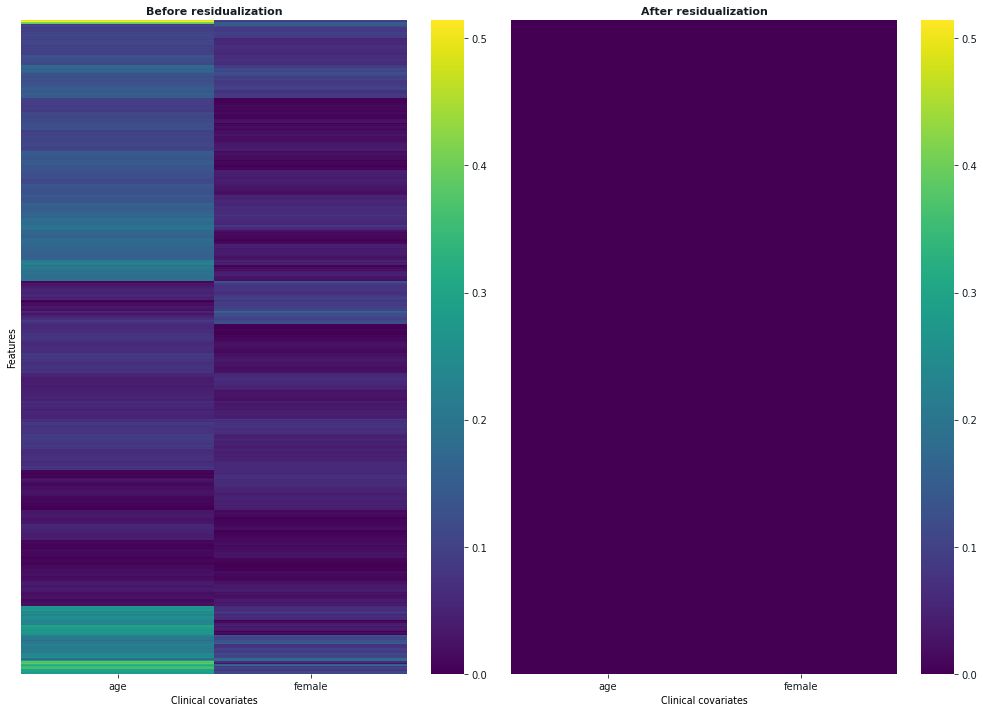

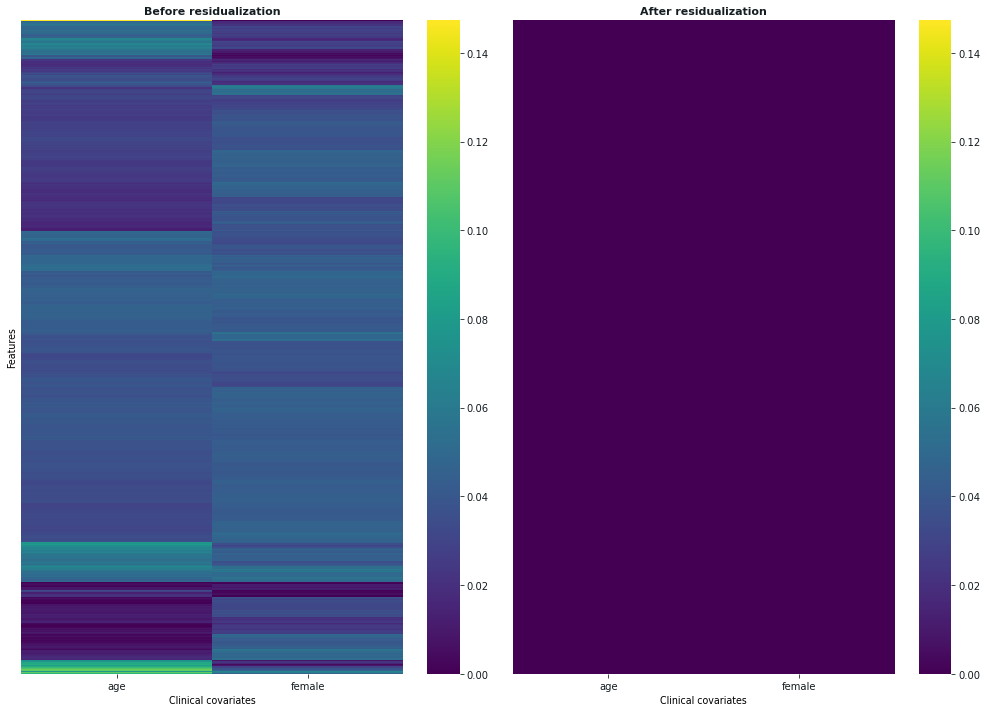

In [15]:
from src2.residualiser import FeatureResidualizer

clinical_covariates_train = ["age", "female"]

# inistlize a non-linear model
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge

# temp_model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=SEED)
temp_model=Ridge(alpha=1.0)

residualizer = FeatureResidualizer(model=temp_model)

X_resid = residualizer.fit_transform(
    d1_coriPreProcess[DEEP_FEATURES],
    d1_coriPreProcess[clinical_covariates_train],
)

residualizer.plot_residualization(
    d1_coriPreProcess[DEEP_FEATURES],
    pd.DataFrame(X_resid, columns=DEEP_FEATURES),
    d1_coriPreProcess[clinical_covariates_train],
)

d1_coriPreProcess_Redisualised = d1_coriPreProcess.copy()
d1_coriPreProcess_Redisualised[DEEP_FEATURES] = residualizer.transform(
    d1_coriPreProcess[DEEP_FEATURES],
    covariates=d1_coriPreProcess[clinical_covariates_train])

d2_coriPreProcess_Redisualised = d2_coriPreProcess.copy()
d2_coriPreProcess_Redisualised[DEEP_FEATURES] = residualizer.transform(
    d2_coriPreProcess[DEEP_FEATURES],
    covariates=d2_coriPreProcess[clinical_covariates_train])

d3_coriPreProcess_Redisualised = d3_coriPreProcess.copy()
d3_coriPreProcess_Redisualised[DEEP_FEATURES] = residualizer.transform(
    d3_coriPreProcess[DEEP_FEATURES],
    covariates=d3_coriPreProcess[clinical_covariates_train])

d4_coriPreProcess_Redisualised = d4_coriPreProcess.copy()
d4_coriPreProcess_Redisualised[DEEP_FEATURES] = residualizer.transform(
    d4_coriPreProcess[DEEP_FEATURES],
    covariates=d4_coriPreProcess[clinical_covariates_train])

 
residualizer = FeatureResidualizer()
X_resid = residualizer.fit_transform(
    d3_MMACEPreProcess[DEEP_FEATURES],
    d3_MMACEPreProcess[clinical_covariates_train],
)

residualizer.plot_residualization(
    d3_MMACEPreProcess[DEEP_FEATURES],
    pd.DataFrame(X_resid, columns=DEEP_FEATURES),
    d3_MMACEPreProcess[clinical_covariates_train],
)

d1_MMACEPreProcess_Redisualised = d1_MMACEPreProcess.copy()
d1_MMACEPreProcess_Redisualised[DEEP_FEATURES] = residualizer.transform(
    d1_MMACEPreProcess[DEEP_FEATURES],
    covariates=d1_MMACEPreProcess[clinical_covariates_train])

d2_MMACEPreProcess_Redisualised = d2_MMACEPreProcess.copy()
d2_MMACEPreProcess_Redisualised[DEEP_FEATURES] = residualizer.transform(
    d2_MMACEPreProcess[DEEP_FEATURES],
    covariates=d2_MMACEPreProcess[clinical_covariates_train])

d3_MMACEPreProcess_Redisualised = d3_MMACEPreProcess.copy()
d3_MMACEPreProcess_Redisualised[DEEP_FEATURES] = residualizer.transform(
    d3_MMACEPreProcess[DEEP_FEATURES],
    covariates=d3_MMACEPreProcess[clinical_covariates_train])

d4_MMACEPreProcess_Redisualised = d4_MMACEPreProcess.copy()
d4_MMACEPreProcess_Redisualised[DEEP_FEATURES] = residualizer.transform(
    d4_MMACEPreProcess[DEEP_FEATURES],
    covariates=d4_MMACEPreProcess[clinical_covariates_train])



# Add to cohort dict

In [16]:

main_cohort_dict['D1_cori'] = d1_coriPreProcess
main_cohort_dict['D2_cori'] = d2_coriPreProcess
main_cohort_dict['D3_cori'] = d3_coriPreProcess
main_cohort_dict['D4_cori'] = d4_coriPreProcess

main_cohort_dict['D1_cori_residualised'] = d1_coriPreProcess_Redisualised
main_cohort_dict['D2_cori_residualised'] = d2_coriPreProcess_Redisualised
main_cohort_dict['D3_cori_residualised'] = d3_coriPreProcess_Redisualised
main_cohort_dict['D4_cori_residualised'] = d4_coriPreProcess_Redisualised

main_cohort_dict['D1_mmace'] = d1_MMACEPreProcess
main_cohort_dict['D2_mmace'] = d2_MMACEPreProcess
main_cohort_dict['D3_mmace'] = d3_MMACEPreProcess
main_cohort_dict['D4_mmace'] = d4_MMACEPreProcess

main_cohort_dict['D1_mmace_residualised'] = d1_MMACEPreProcess_Redisualised
main_cohort_dict['D2_mmace_residualised'] = d2_MMACEPreProcess_Redisualised
main_cohort_dict['D3_mmace_residualised'] = d3_MMACEPreProcess_Redisualised
main_cohort_dict['D4_mmace_residualised'] = d4_MMACEPreProcess_Redisualised

In [17]:
# train_X = pd.concat([d1_coriPreProcess[['eid'] + DEEP_FEATURES],
#                      d3_coriPreProcess [['eid'] + DEEP_FEATURES]], 
#                     ignore_index=True).to_numpy()
# train_Y1 = [1] * len(d1_coriPreProcess) + [0] * len(d3_coriPreProcess)
# train_Y2 = d1_coriPreProcess['Y_mace'].tolist() + d3_coriPreProcess['Y_mace'].tolist()

# train_df = pd.DataFrame(train_X)
# train_df['Y_cancer'] = train_Y1
# train_df['Y_mace'] = train_Y2


# test_X = pd.concat([d2_coriPreProcess[['eid'] + DEEP_FEATURES],
#                     d4_coriPreProcess [['eid'] + DEEP_FEATURES]], 
#                    ignore_index=True).to_numpy()
# test_Y1 = [1] * len(d2_coriPreProcess) + [0] * len(d4_coriPreProcess)
# test_Y2 = d2_coriPreProcess['Y_mace'].tolist() + d4_coriPreProcess['Y_mace'].tolist()

# test_df = pd.DataFrame(test_X)
# test_df['Y_cancer'] = test_Y1
# test_df['Y_mace'] = test_Y2


# Hparam selection

In [18]:
DEEP_FEATURES = [f"f{i}" for i in range(1024)]

overlap_feats = ['f370', 'f501', 'f355', 'f940', 'f323', 'f657', 'f51', 'f74', 'f620', 'f811', 'f509', 'f6', 'f242', 'f275', 'f689', 'f832', 'f762', 'f438', 'f737', 'f424', 'f792', 'f867', 'f183', 'f18']
cancerOnly_feats = ['f513', 'f771', 'f507', 'f250', 'f443', 'f666', 'f976', 'f339', 'f95', 'f240', 'f721', 'f836', 'f907', 'f385', 'f727', 'f537', 'f686', 'f604', 'f731', 'f866', 'f497', 'f729', 'f944', 'f110', 'f459', 'f350', 'f89', 'f584', 'f22', 'f704', 'f534', 'f347', 'f775', 'f523', 'f955', 'f263', 'f340', 'f10', 'f177', 'f137', 'f557', 'f542', 'f72', 'f431', 'f284', 'f699', 'f121', 'f1011', 'f578', 'f34', 'f113', 'f441', 'f194', 'f682']
maceOnly_feats = ['f603', 'f405', 'f717', 'f80', 'f217', 'f1021', 'f471', 'f156', 'f477', 'f328', 'f176', 'f521', 'f354', 'f260', 'f196', 'f986', 'f935', 'f185', 'f369', 'f322', 'f546', 'f767', 'f693', 'f440', 'f586', 'f427', 'f644', 'f416', 'f869', 'f552', 'f941', 'f927', 'f873', 'f247', 'f587', 'f989', 'f967', 'f5', 'f561', 'f79', 'f556', 'f725', 'f826', 'f188', 'f285', 'f929', 'f12', 'f909', 'f565', 'f338', 'f518', 'f994']


## CORI hparam

In [19]:
# # Equal search opportunity: same grid, folds, repeats, and one-SE rule.
# cori_tuned_model, cori_tuning, cori_tuning_choice = tune_model_cv(
#     main_cohort_dict["D1_cori"],
#     cancerOnly_feats,
#     name="CORI_tuned",
#     candidate_k=TUNING_K,
#     candidate_penalizers=TUNING_PENALTIES,
#     folds=TUNING_FOLDS,
#     repeats=TUNING_REPEATS,
#     seed=SEED,
#     rule=TUNING_RULE,
# )

# print(cori_tuned_model.feature_columns)
# print(cori_tuning_choice)

# cori_tuning['sd_c_neg'] = cori_tuning['sd_C'].round(3) * -1
# cori_tuning['mean_C_round'] = cori_tuning['mean_C'].round(3)
# cori_tuning.sort_values(by=['mean_C_round', 'sd_c_neg'], ascending=False).head(10)

In [20]:
# Equal search opportunity: same grid, folds, repeats, and one-SE rule.
cori_tuned_model, cori_tuning, cori_tuning_choice = tune_model_cv(
    main_cohort_dict["D1_cori_residualised"],
    DEEP_FEATURES,
    name="CORI_tuned",
    candidate_k=TUNING_K,
    candidate_penalizers=TUNING_PENALTIES,
    folds=TUNING_FOLDS,
    repeats=TUNING_REPEATS,
    seed=SEED,
    rule=TUNING_RULE,
)

print(cori_tuned_model.feature_columns)
print(cori_tuning_choice)

cori_tuning['sd_c_neg'] = cori_tuning['sd_C'].round(3) * -1
cori_tuning['mean_C_round'] = cori_tuning['mean_C'].round(3)
cori_tuning.sort_values(by=['mean_C_round', 'sd_c_neg'], ascending=False).head(10)

['f621', 'f98', 'f418', 'f714', 'f622', 'f239', 'f319', 'f469', 'f539', 'f583']
{'rule': 'one_se', 'n_features': 10, 'penalizer': 0.1, 'mean_internal_C': 0.4853098953443404, 'best_internal_C': 0.4853098953443404, 'cv_splits': 9}


,n_features,penalizer,mean_C,sd_C,n,se_C,sd_c_neg,mean_C_round
3,10,0.100,0.485310,0.010595,9,0.003532,-0.011,0.485
2,10,0.050,0.483664,0.010475,9,0.003492,-0.010,0.484
1,10,0.010,0.481713,0.010766,9,0.003589,-0.011,0.482
0,10,0.001,0.481050,0.010815,9,0.003605,-0.011,0.481
11,20,0.100,0.479765,0.017188,9,0.005729,-0.017,0.480
7,15,0.100,0.478885,0.014183,9,0.004728,-0.014,0.479
10,20,0.050,0.478120,0.018710,9,0.006237,-0.019,0.478
8,20,0.001,0.478124,0.023669,9,0.007890,-0.024,0.478
6,15,0.050,0.477178,0.014525,9,0.004842,-0.015,0.477
9,20,0.010,0.477180,0.021889,9,0.007296,-0.022,0.477


## MMACE hparam

In [21]:

# mmace_tuned_model, mmace_tuning, mmace_tuning_choice = tune_model_cv(
#     main_cohort_dict["D3_mmace"],
#     maceOnly_feats,
#     name="MMACE_tuned",
#     candidate_k=TUNING_K,
#     candidate_penalizers=TUNING_PENALTIES,
#     folds=TUNING_FOLDS,
#     repeats=TUNING_REPEATS,
#     seed=SEED,
#     rule=TUNING_RULE,
# )

# print(mmace_tuned_model.feature_columns)
# print(mmace_tuning_choice)

# mmace_tuning['sd_c_neg'] = mmace_tuning['sd_C'].round(3) * -1
# mmace_tuning['mean_C_round'] = mmace_tuning['mean_C'].round(3)
# mmace_tuning.sort_values(by=['mean_C_round', 'sd_c_neg'], ascending=False).head(10)

In [22]:

mmace_tuned_model, mmace_tuning, mmace_tuning_choice = tune_model_cv(
    main_cohort_dict["D3_mmace_residualised"],
    DEEP_FEATURES,
    name="MMACE_tuned",
    candidate_k=TUNING_K,
    candidate_penalizers=TUNING_PENALTIES,
    folds=TUNING_FOLDS,
    repeats=TUNING_REPEATS,
    seed=SEED,
    rule=TUNING_RULE,
)

print(mmace_tuned_model.feature_columns)
print(mmace_tuning_choice)

mmace_tuning['sd_c_neg'] = mmace_tuning['sd_C'].round(3) * -1
mmace_tuning['mean_C_round'] = mmace_tuning['mean_C'].round(3)
mmace_tuning.sort_values(by=['mean_C_round', 'sd_c_neg'], ascending=False).head(10)

['f929', 'f260', 'f12', 'f689', 'f657', 'f565', 'f111', 'f80', 'f994', 'f242', 'f185', 'f1022', 'f508', 'f941', 'f629']
{'rule': 'one_se', 'n_features': 15, 'penalizer': 0.001, 'mean_internal_C': 0.46943892077123883, 'best_internal_C': 0.4696658317004142, 'cv_splits': 9}


,n_features,penalizer,mean_C,sd_C,n,se_C,sd_c_neg,mean_C_round
8,20,0.001,0.469666,0.019664,9,0.006555,-0.020,0.470
4,15,0.001,0.469439,0.017582,9,0.005861,-0.018,0.469
0,10,0.001,0.456148,0.012566,9,0.004189,-0.013,0.456
3,10,0.100,0.451590,0.010099,9,0.003366,-0.010,0.452
2,10,0.050,0.450827,0.010299,9,0.003433,-0.010,0.451
5,15,0.010,0.451354,0.012444,9,0.004148,-0.012,0.451
9,20,0.010,0.450898,0.012874,9,0.004291,-0.013,0.451
7,15,0.100,0.449564,0.010154,9,0.003385,-0.010,0.450
6,15,0.050,0.449194,0.010464,9,0.003488,-0.010,0.449
1,10,0.010,0.449189,0.011373,9,0.003791,-0.011,0.449


# Train model

In [23]:
from src2.train import train_cox_model

# cori_features = ['f98', 'f260', 'f989', 'f728', 'f319', 'f80', 'f440', 'f735', 'f689', 'f119'] 
# mmace_features = ['f319', 'f0', 'f54', 'f265', 'f248', 'f4', 'f742', 'f517', 'f380', 'f494']

cori_features =  sorted(cori_tuned_model.feature_columns)
mmace_features =  sorted(mmace_tuned_model.feature_columns)

print(cori_features)
print(mmace_features)

['f239', 'f319', 'f418', 'f469', 'f539', 'f583', 'f621', 'f622', 'f714', 'f98']
['f1022', 'f111', 'f12', 'f185', 'f242', 'f260', 'f508', 'f565', 'f629', 'f657', 'f689', 'f80', 'f929', 'f941', 'f994']


## Test CORI on D2

 train shape: (2156, 1089)
 test shape: (2435, 1089)


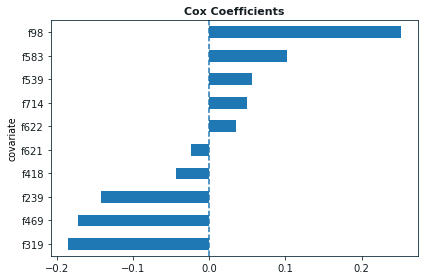

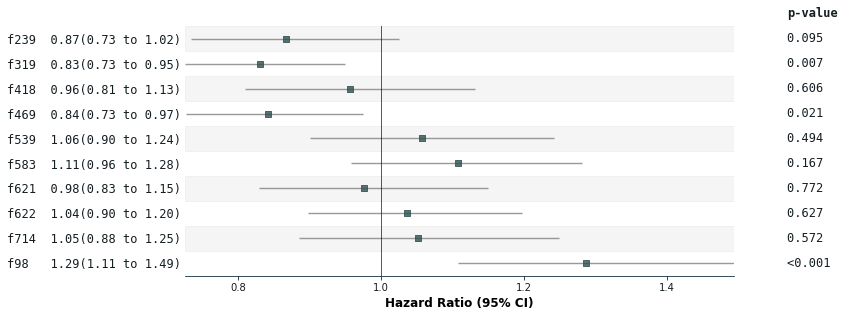

Using provided percentiles: [0, 0.8, 1]

Hazard Ratios (Train) -- each vs ref group
  High risk vs Low risk: HR = 1.900 (95% CI 1.495 - 2.416), p = 1.57e-07

Hazard Ratios (Test)  -- each vs ref group
  High risk vs Low risk: HR = 1.788 (95% CI 1.424 - 2.244), p = 5.46e-07
Train: pval 0.0 cindex 0.6308
Test: pval 0.0 cindex 0.6099


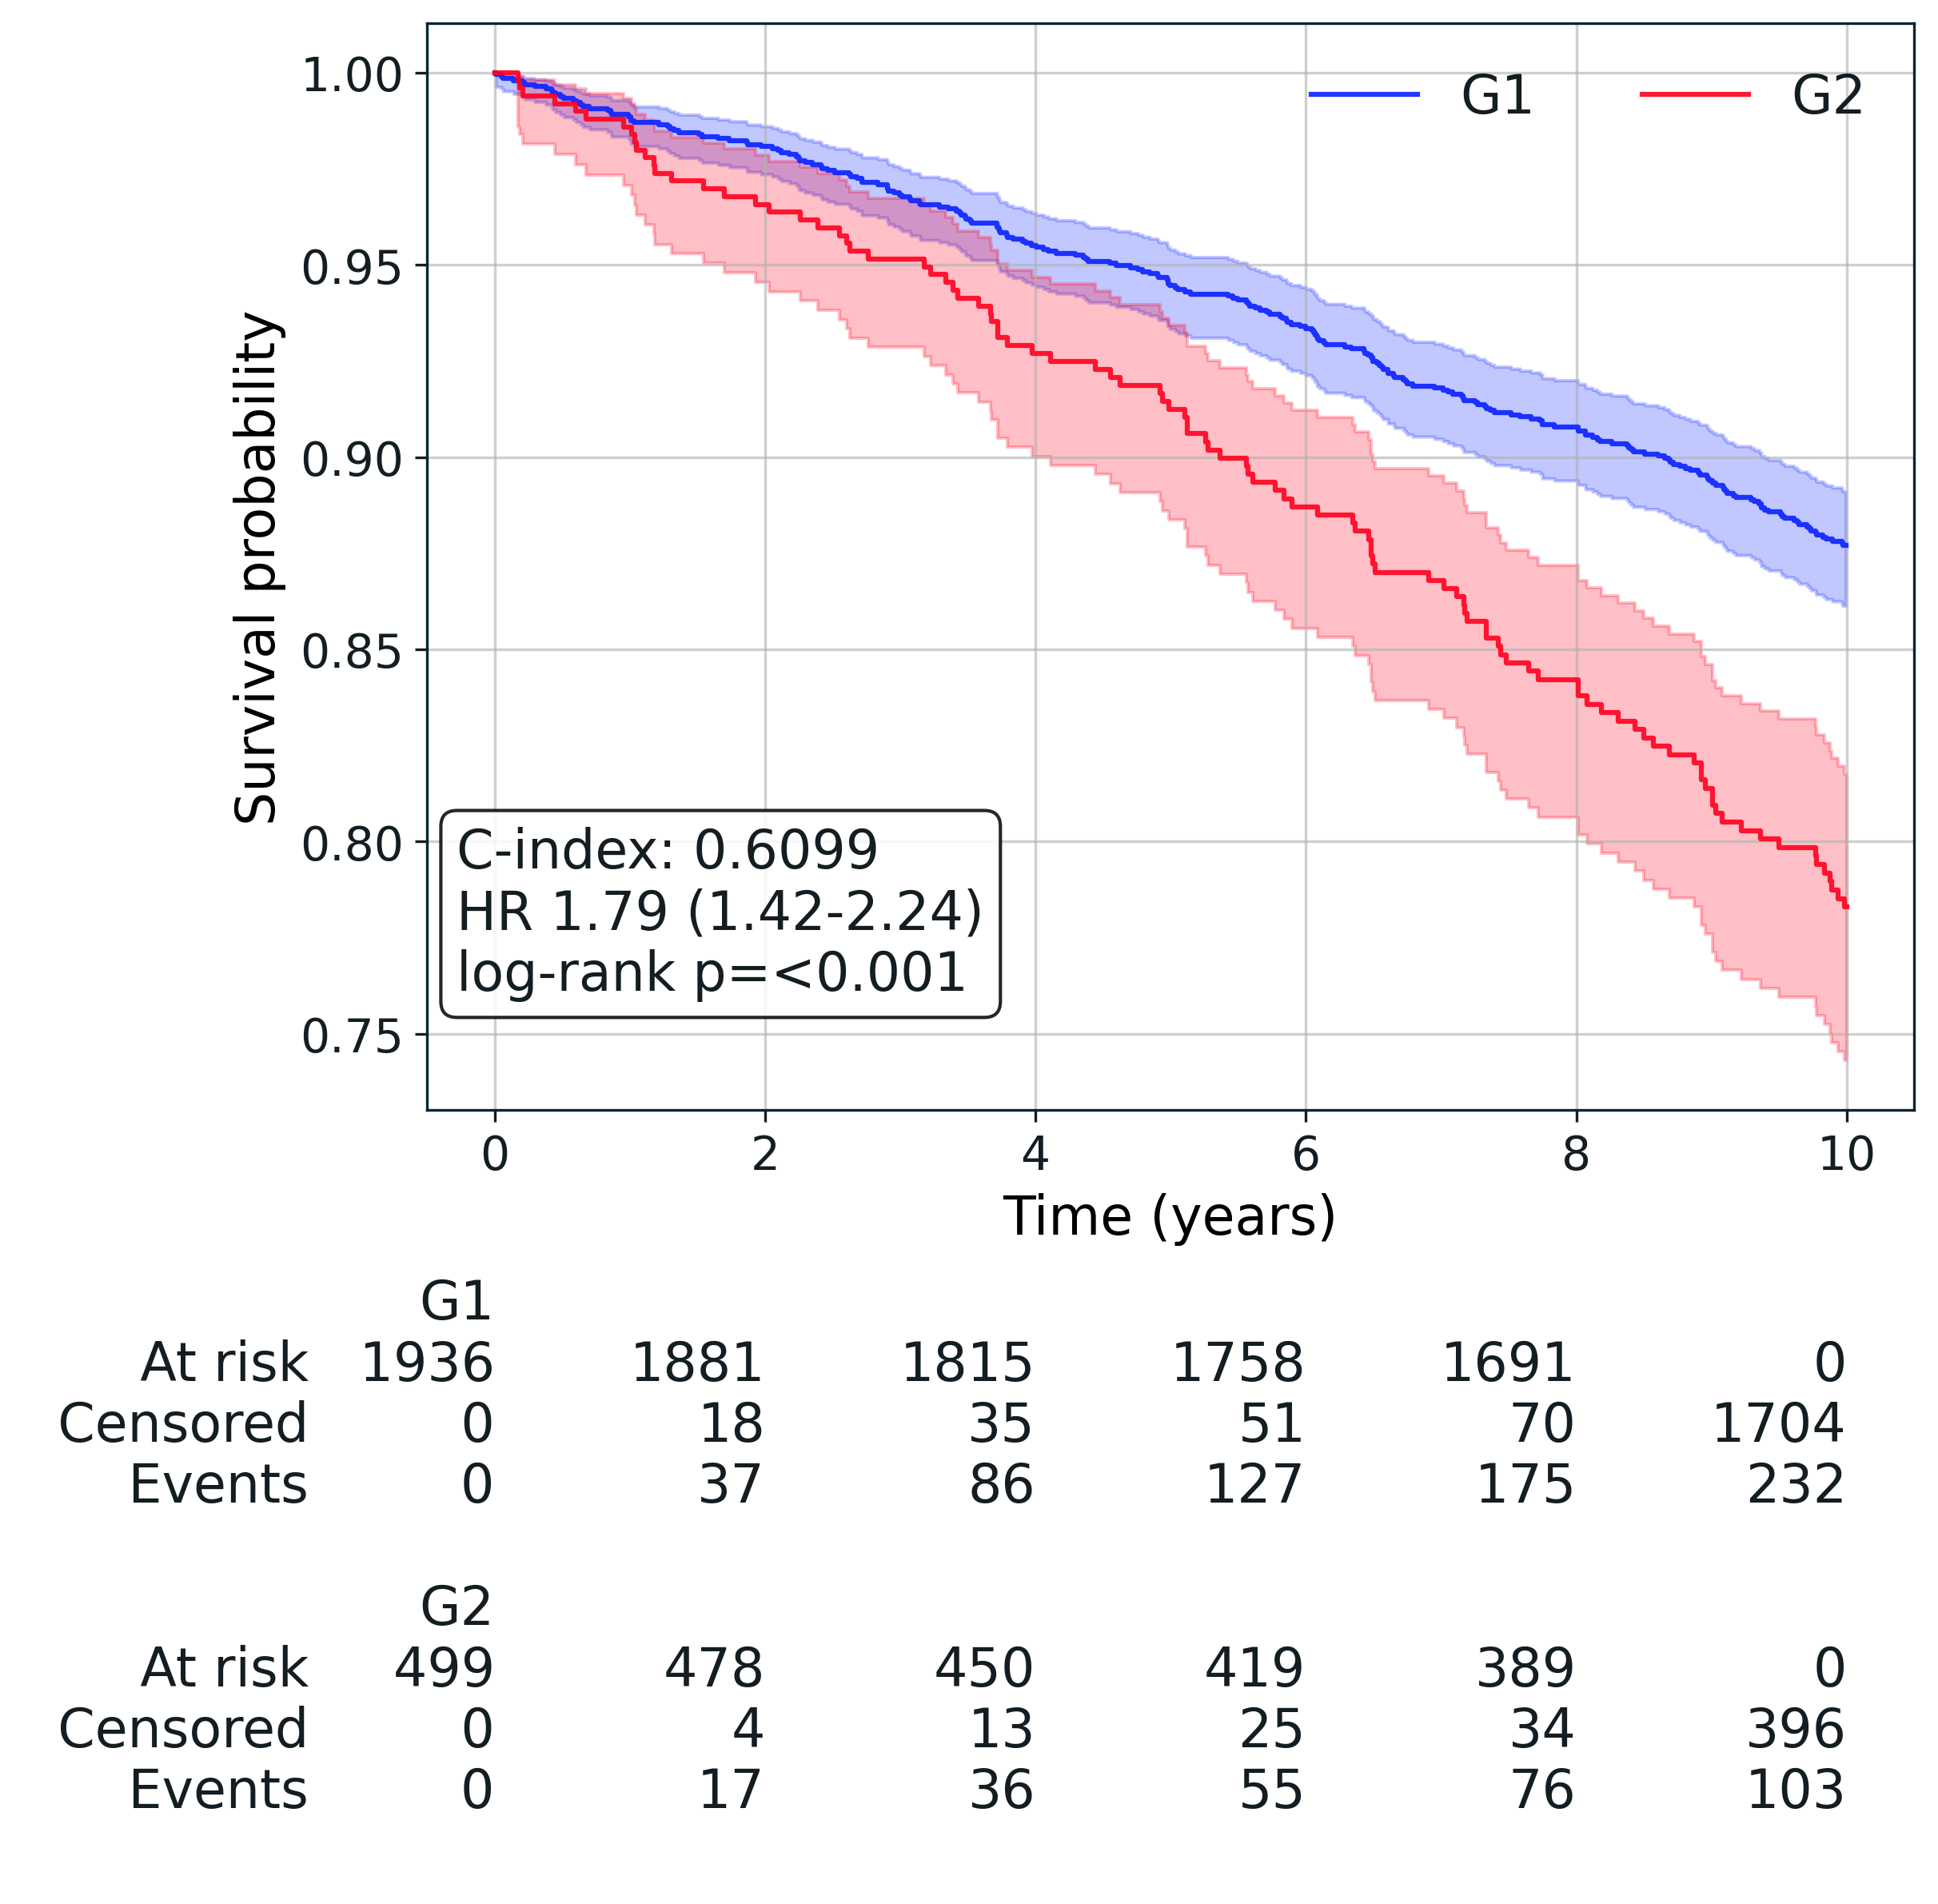

In [26]:
col_list = cori_features

temp_train_df = main_cohort_dict["D1_cori"].copy().dropna(subset=col_list)
temp_test_df = main_cohort_dict["D2_cori"].copy().dropna(subset=col_list)

# temp_train_df = main_cohort_dict["D1_cori_residualised"].copy().dropna(subset=col_list)
# temp_test_df = main_cohort_dict["D2_cori_residualised"].copy().dropna(subset=col_list)


outputs = train_cox_model(
    temp_train_df,
    temp_test_df,
    selected_features=col_list,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    verbose=True,
    plot_groups=[2],
    percentiles=[0, 0.8, 1],
    penalizer = 0.01
)
# plt.savefig(FIGURE_DIR + "kmcurve_snap.svg", dpi=300, bbox_inches="tight")

temp_train_df['CORI_risk_score'] = outputs["train_df"]['risk_score']
temp_test_df['CORI_risk_score'] = outputs["test_df"]['risk_score']
results = outputs["results"]

cori_train_median_risk = temp_train_df['CORI_risk_score'].median()
temp_train_df['CORI_risk_score_group'] = temp_train_df['CORI_risk_score'].apply(lambda x: 1 if x >= cori_train_median_risk else 0)
temp_test_df['CORI_risk_score_group'] = temp_test_df['CORI_risk_score'].apply(lambda x: 1 if x >= cori_train_median_risk else 0)

cori_train_df = temp_train_df.copy()
cori_test_df = temp_test_df.copy()

## adding for SHAP analysis
cori_model    = outputs["cox_model"]
cori_features = col_list  

print("Train: pval",  round(results['train']['p_value'], 4), "cindex", round(results['train']['c_index'], 4) )
print("Test: pval",  round(results['test']['p_value'], 4), "cindex", round(results['test']['c_index'], 4) )


In [27]:

label_map = {
    "CORI_risk_score": "CORI",
    "age": "Age (years)",
    "sex": "Male vs Female",
    "height": "Height (cm)",
    "BMI": "BMI (kg/m2)",
    "systolic_bp": "Systolic BP (mmHg)",
    "cholesterol": "Cholesterol (mmol/L)",
    "exercise": "Physical Activity",
    "Diabetes": "Diabetes",
    "HTN": "Hypertension",
    "Years_of_Education": "Literacy",
    "waist_circumference": "Waist Circumference (cm)",
    "center_intLabel": "Center",
}

## Test CORI on D2, 3/5/10 year horizon

In [28]:


# # Supplementary Figure 6. Event-horizon performance

# hp = horizon_performance.sort_values("horizon_years")
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.0), layout="constrained")

# ax1.errorbar(
#     hp["horizon_years"], hp["C_index"],
#     yerr=[hp["C_index"]-hp["C_low"], hp["C_high"]-hp["C_index"]],
#     color=CORI, marker="o", linewidth=1.8, capsize=3,
# )
# ax1.set_xticks(hp["horizon_years"])
# ax1.set_ylim(0.54, 0.72)
# ax1.set_xlabel("Prediction horizon, years")
# ax1.set_ylabel("C-index (95% CI)")
# ax1.set_title("CORI discrimination")
# clean_axes(ax1, "both")
# panel_letter(ax1, "A")

# ax2.errorbar(
#     hp["horizon_years"], hp["HR"],
#     yerr=[hp["HR"]-hp["HR_low"], hp["HR_high"]-hp["HR"]],
#     color=CORAL, marker="o", linewidth=1.8, capsize=3,
# )
# ax2.axhline(1, color=GRAY, linestyle="--")
# ax2.set_xticks(hp["horizon_years"])
# ax2.set_xlabel("Prediction horizon, years")
# ax2.set_ylabel("High- versus low-CORI HR (95% CI)")
# ax2.set_title("CORI risk separation")
# clean_axes(ax2, "both")
# panel_letter(ax2, "B")

# save_figure(fig, "Supplementary_Figure6_event_horizons")
# plt.show()


## Test MMACE on D4

 train shape: (14159, 1069)
 test shape: (14763, 1069)


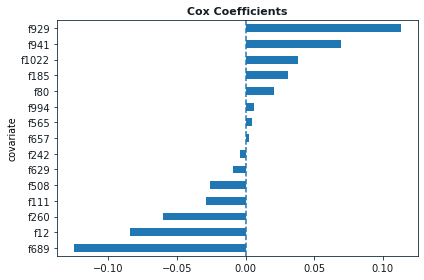

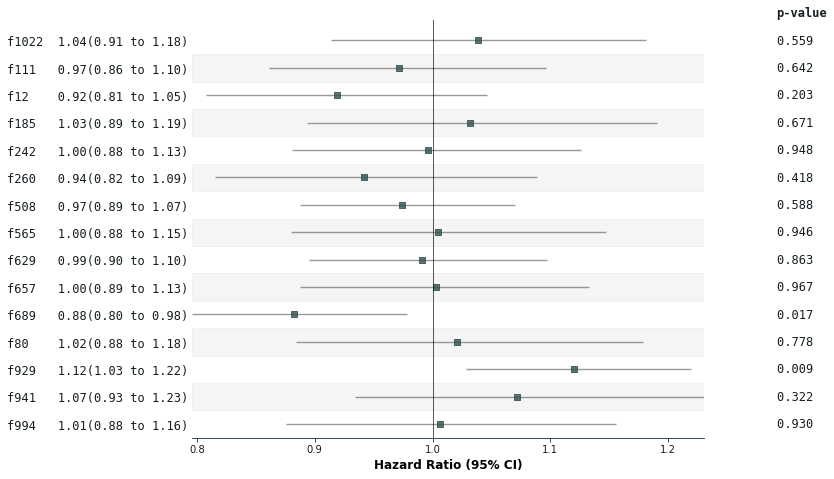

Using provided percentiles: [0, 0.8, 1]

Hazard Ratios (Train) -- each vs ref group
  High risk vs Low risk: HR = 2.486 (95% CI 2.234 - 2.766), p = 1.32e-62

Hazard Ratios (Test)  -- each vs ref group
  High risk vs Low risk: HR = 2.600 (95% CI 2.319 - 2.915), p = 3.23e-60
Train: pval 0.0 cindex 0.6154
Test: pval 0.0 cindex 0.6029


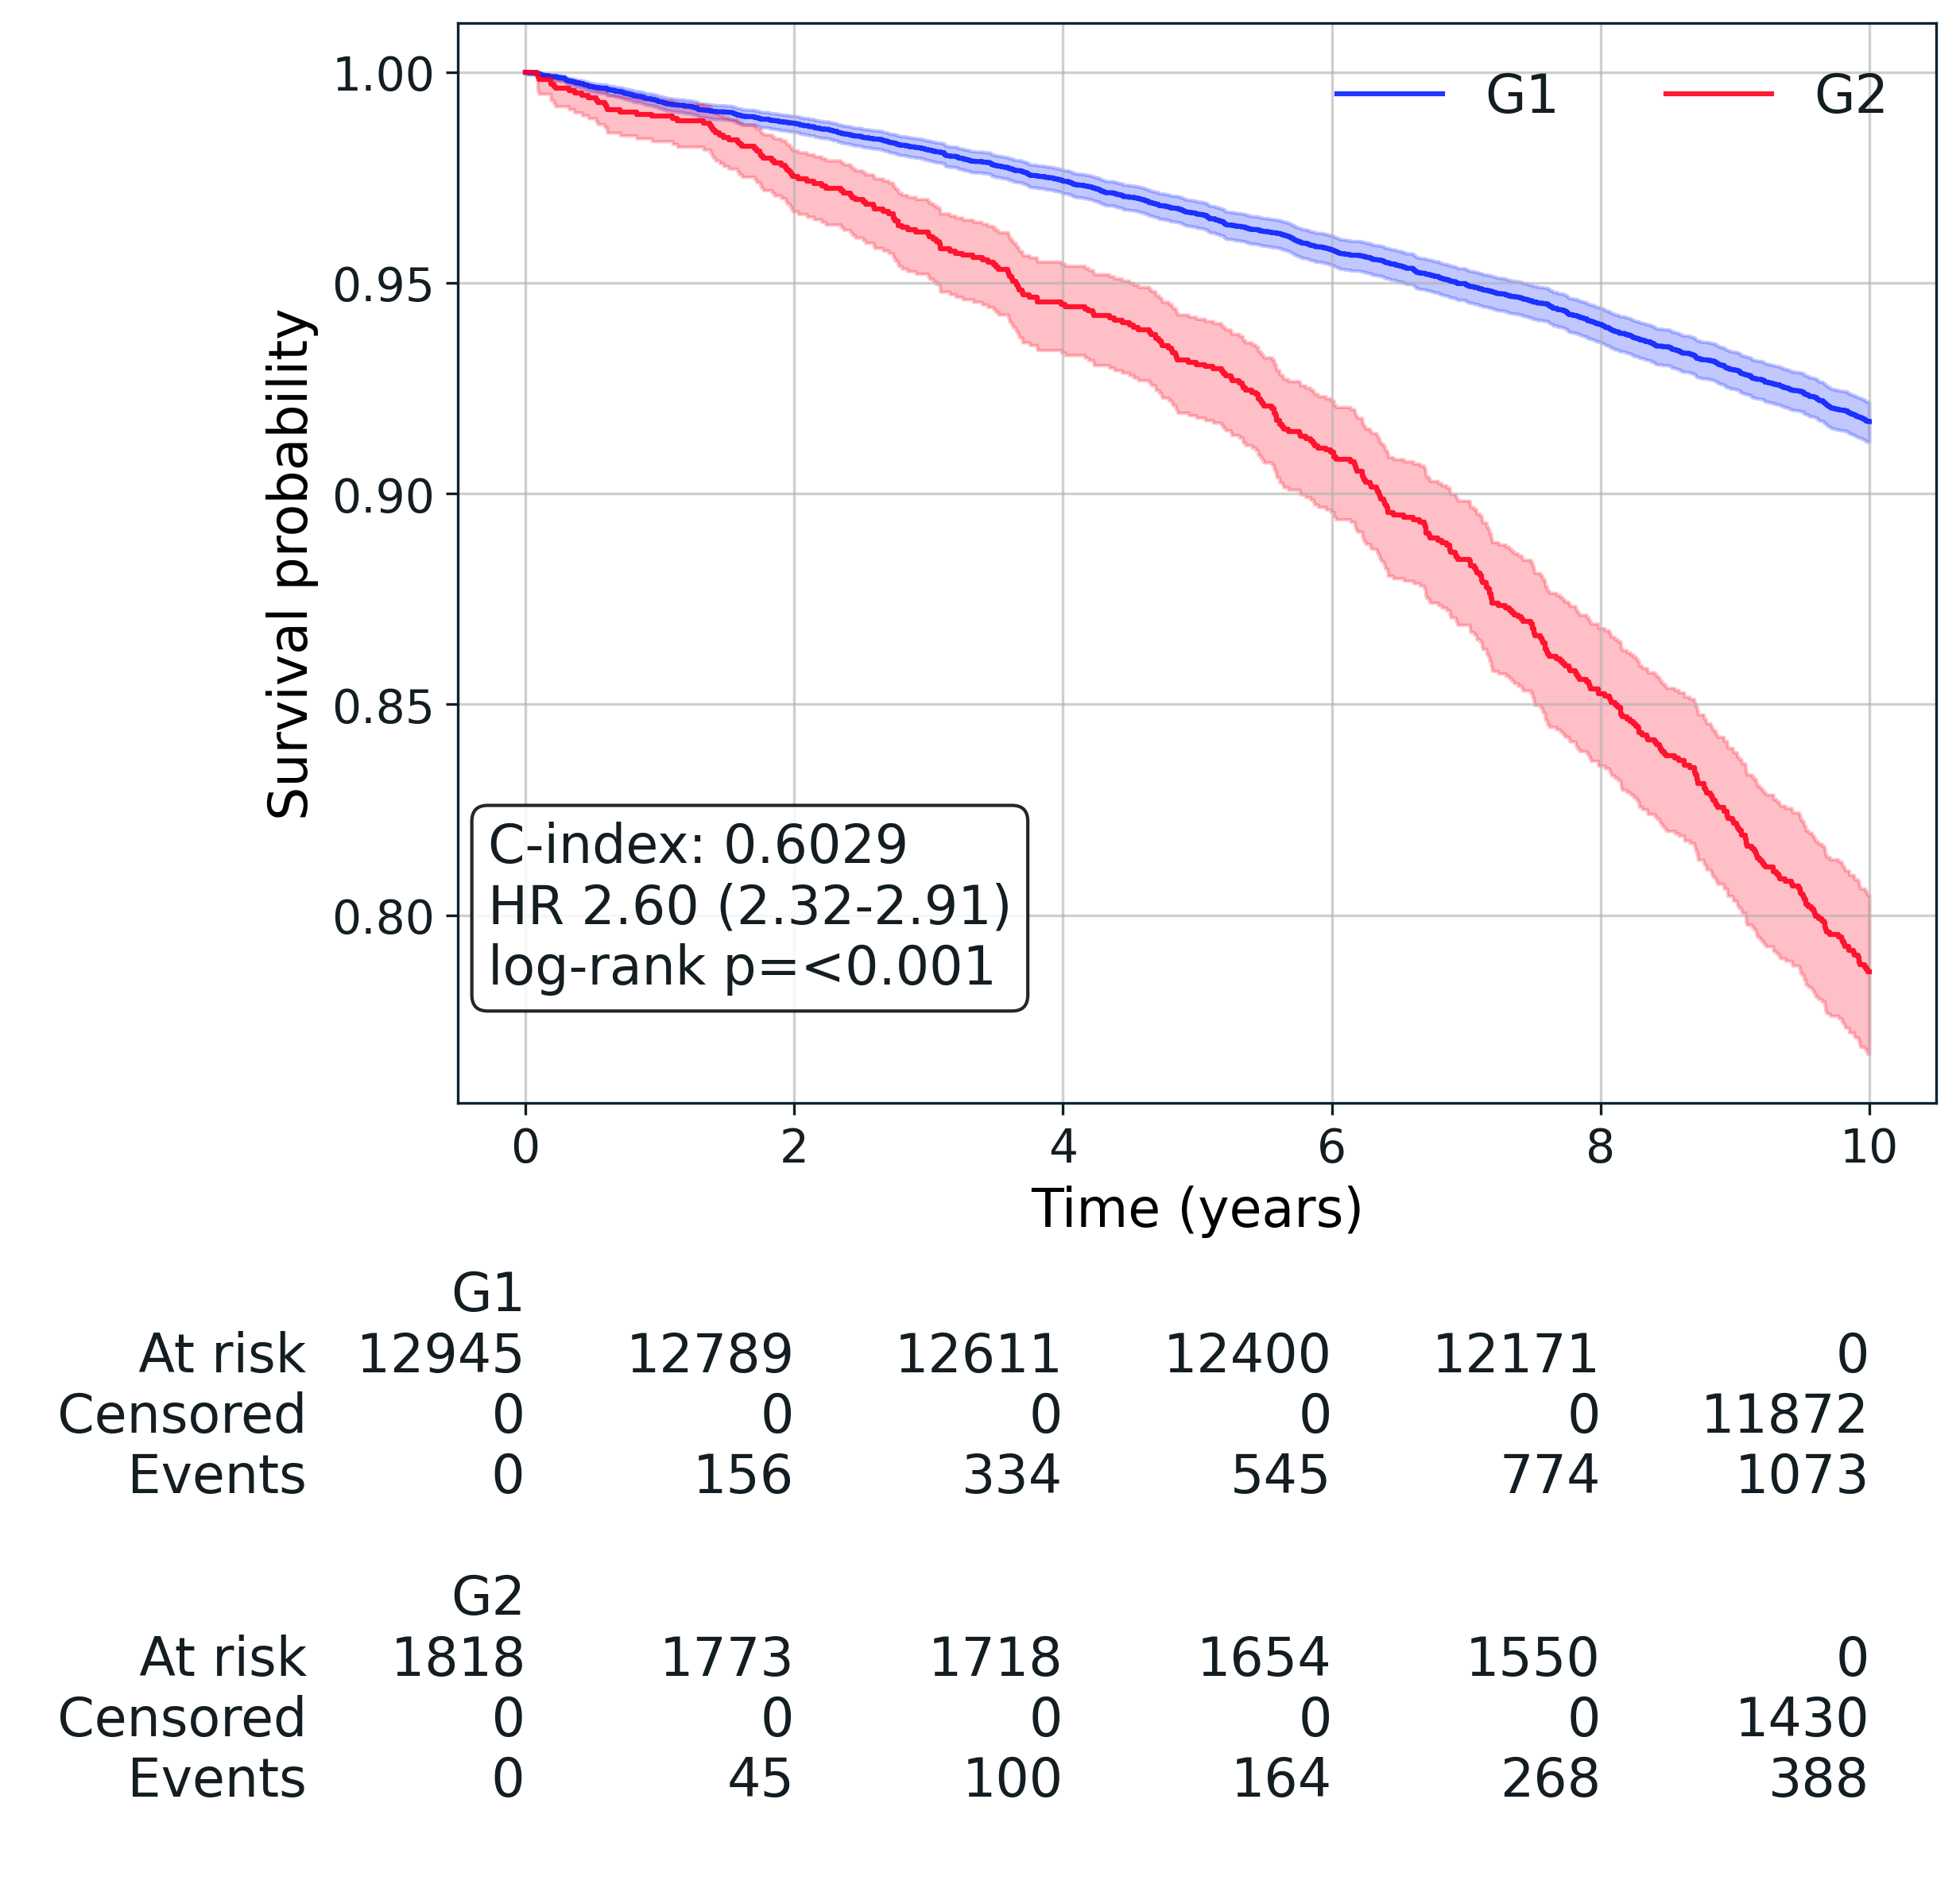

In [30]:
col_list = mmace_features

temp_train_df = main_cohort_dict["D3_mmace"].copy().dropna(subset=col_list)
temp_test_df = main_cohort_dict["D4_mmace"].copy().dropna(subset=col_list)

# temp_train_df = main_cohort_dict["D3_mmace_residualised"].copy().dropna(subset=col_list)
# temp_test_df = main_cohort_dict["D4_mmace_residualised"].copy().dropna(subset=col_list)


outputs = train_cox_model(
    temp_train_df,
    temp_test_df,
    selected_features=col_list,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    verbose=True,
    plot_groups=[2],
    percentiles=[0, 0.8, 1],
    penalizer = 0.01
)
# plt.savefig(FIGURE_DIR + "kmcurve_snap.svg", dpi=300, bbox_inches="tight")

temp_train_df['MMACE_risk_score'] = outputs["train_df"]['risk_score']
temp_test_df['MMACE_risk_score'] = outputs["test_df"]['risk_score']
results = outputs["results"]

mmace_train_median_risk = temp_train_df['MMACE_risk_score'].median()
temp_train_df['MMACE_risk_score_group'] = temp_train_df['MMACE_risk_score'].apply(lambda x: 1 if x >= mmace_train_median_risk else 0)
temp_test_df['MMACE_risk_score_group'] = temp_test_df['MMACE_risk_score'].apply(lambda x: 1 if x >= mmace_train_median_risk else 0)

mmace_train_df = temp_train_df.copy()
mmace_test_df = temp_test_df.copy()

## adding for SHAP analysis
mmace_model    = outputs["cox_model"]
mmace_features = col_list  

print("Train: pval",  round(results['train']['p_value'], 4), "cindex", round(results['train']['c_index'], 4) )
print("Test: pval",  round(results['test']['p_value'], 4), "cindex", round(results['test']['c_index'], 4) )
 

## Clinical model on D2

In [31]:
col_list = CLINICAL_VARIABLES

temp_train_df = cori_train_df .copy().dropna(subset=col_list)
temp_test_df = cori_test_df .copy().dropna(subset=col_list)

outputs = train_cox_model(
    temp_train_df,
    temp_test_df,
    selected_features=col_list,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    verbose=True,
    plot_groups=[2],
)
# plt.savefig(FIGURE_DIR + "kmcurve_snap.svg", dpi=300, bbox_inches="tight")

temp_train_df['clinical_risk_score'] = outputs["train_df"]['risk_score']
temp_test_df['clinical_risk_score'] = outputs["test_df"]['risk_score']
results = outputs["results"]

clinical_train_median_risk = temp_train_df['clinical_risk_score'].median()
temp_train_df['clinical_risk_score_group'] = temp_train_df['clinical_risk_score'].apply(lambda x: 1 if x >= clinical_train_median_risk else 0)
temp_test_df['clinical_risk_score_group'] = temp_test_df['clinical_risk_score'].apply(lambda x: 1 if x >= clinical_train_median_risk else 0)

clinical_train_df = temp_train_df.copy()
clinical_test_df = temp_test_df.copy()

## adding for SHAP analysis
clinical_model    = outputs["cox_model"]
# clinical_features = col_list  

print("Train: pval",  round(results['train']['p_value'], 4), "cindex", round(results['train']['c_index'], 4) )
print("Test: pval",  round(results['test']['p_value'], 4), "cindex", round(results['test']['c_index'], 4) )


 train shape: (2156, 1091)
 test shape: (2435, 1091)


TypeError: '>' not supported between instances of 'NoneType' and 'int'

# Residualisation

## CORI residualised for MMACE

## CORI residualised for cancer type labels

# Cross Testing

## Test CORI on D4

 train shape: (2156, 1089)
 test shape: (14763, 1069)


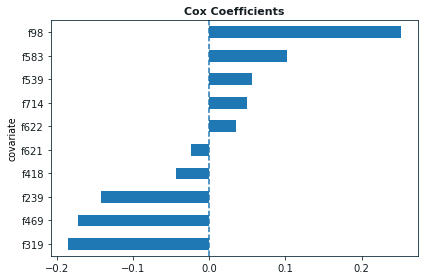

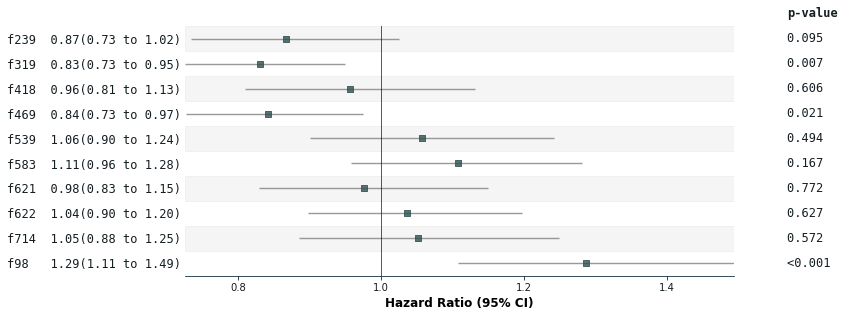

Using provided percentiles: [0, 0.8, 1]

Hazard Ratios (Train) -- each vs ref group
  High risk vs Low risk: HR = 1.900 (95% CI 1.495 - 2.416), p = 1.57e-07

Hazard Ratios (Test)  -- each vs ref group
  High risk vs Low risk: HR = 3.696 (95% CI 2.037 - 6.706), p = 1.71e-05
Train: pval 0.0 cindex 0.6308
Test: pval 0.0 cindex 0.4453


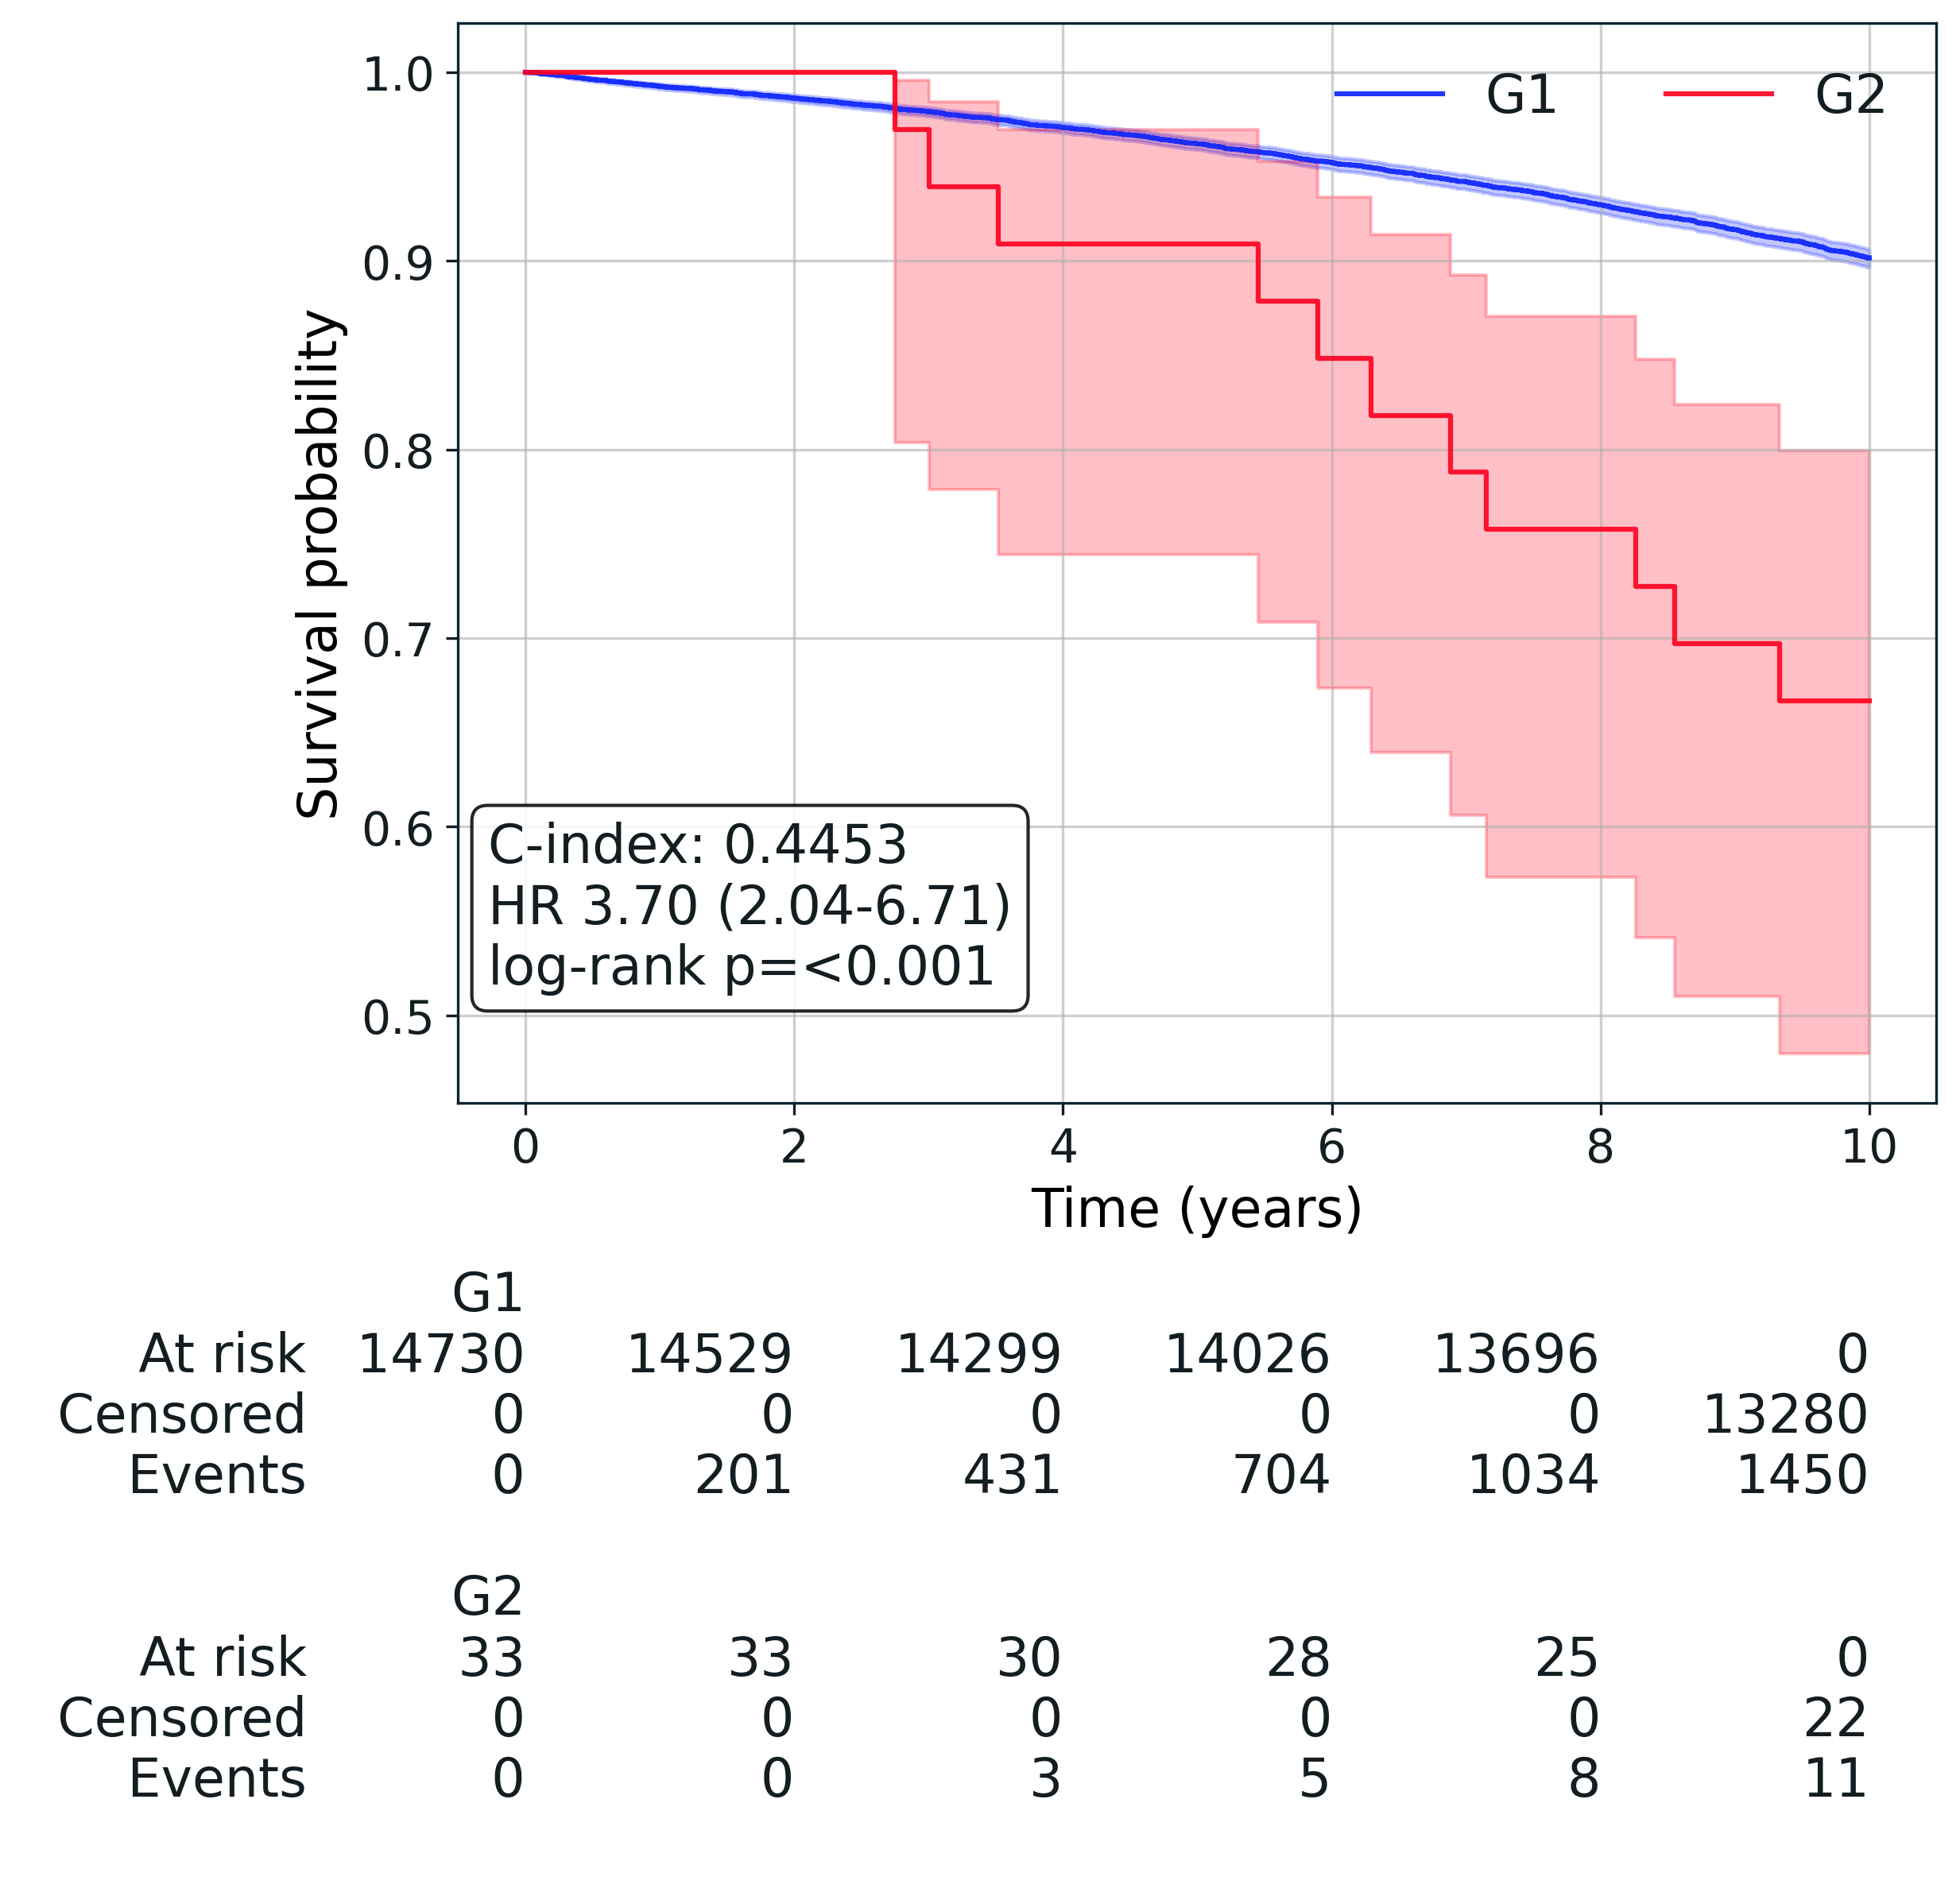

In [32]:
col_list = cori_features

temp_train_df = main_cohort_dict["D1_cori"].copy().dropna(subset=col_list)
temp_test_df = main_cohort_dict["D4_cori"].copy().dropna(subset=col_list)

outputs = train_cox_model(
    temp_train_df,
    temp_test_df,
    selected_features=col_list,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    verbose=True,
    plot_groups=[2],
    percentiles=[0, 0.8, 1],
    penalizer = 0.01
)
# plt.savefig(FIGURE_DIR + "kmcurve_snap.svg", dpi=300, bbox_inches="tight")

temp_train_df['MMACE_risk_score'] = outputs["train_df"]['risk_score']
temp_test_df['MMACE_risk_score'] = outputs["test_df"]['risk_score']


results = outputs["results"]

train_median_risk = temp_train_df['MMACE_risk_score'].median()
temp_train_df['MMACE_risk_score_group'] = temp_train_df['MMACE_risk_score'].apply(lambda x: 1 if x >= train_median_risk else 0)
temp_test_df['MMACE_risk_score_group'] = temp_test_df['MMACE_risk_score'].apply(lambda x: 1 if x >= train_median_risk else 0)

MMACE_D3train_df = temp_train_df.copy()
MMACE_D2test_df = temp_test_df.copy()

## adding for SHAP analysis
cori_model    = outputs["cox_model"]
cori_features = col_list  

print("Train: pval",  round(results['train']['p_value'], 4), "cindex", round(results['train']['c_index'], 4) )
print("Test: pval",  round(results['test']['p_value'], 4), "cindex", round(results['test']['c_index'], 4) )


## Test MMACE on D2

 train shape: (14159, 1069)
 test shape: (2156, 1089)


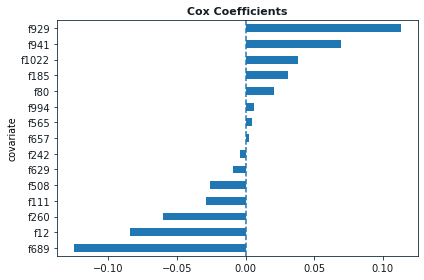

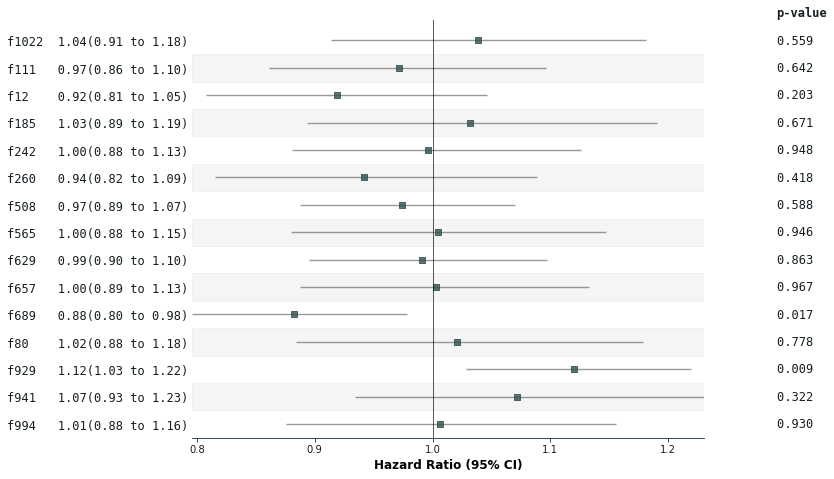

Using provided percentiles: [0, 0.8, 1]

Hazard Ratios (Train) -- each vs ref group
  High risk vs Low risk: HR = 2.486 (95% CI 2.234 - 2.766), p = 1.32e-62

Hazard Ratios (Test)  -- each vs ref group
  High risk vs Low risk: HR = 1.684 (95% CI 1.313 - 2.161), p = 4.07e-05
Train: pval 0.0 cindex 0.6154
Test: pval 0.0 cindex 0.5961


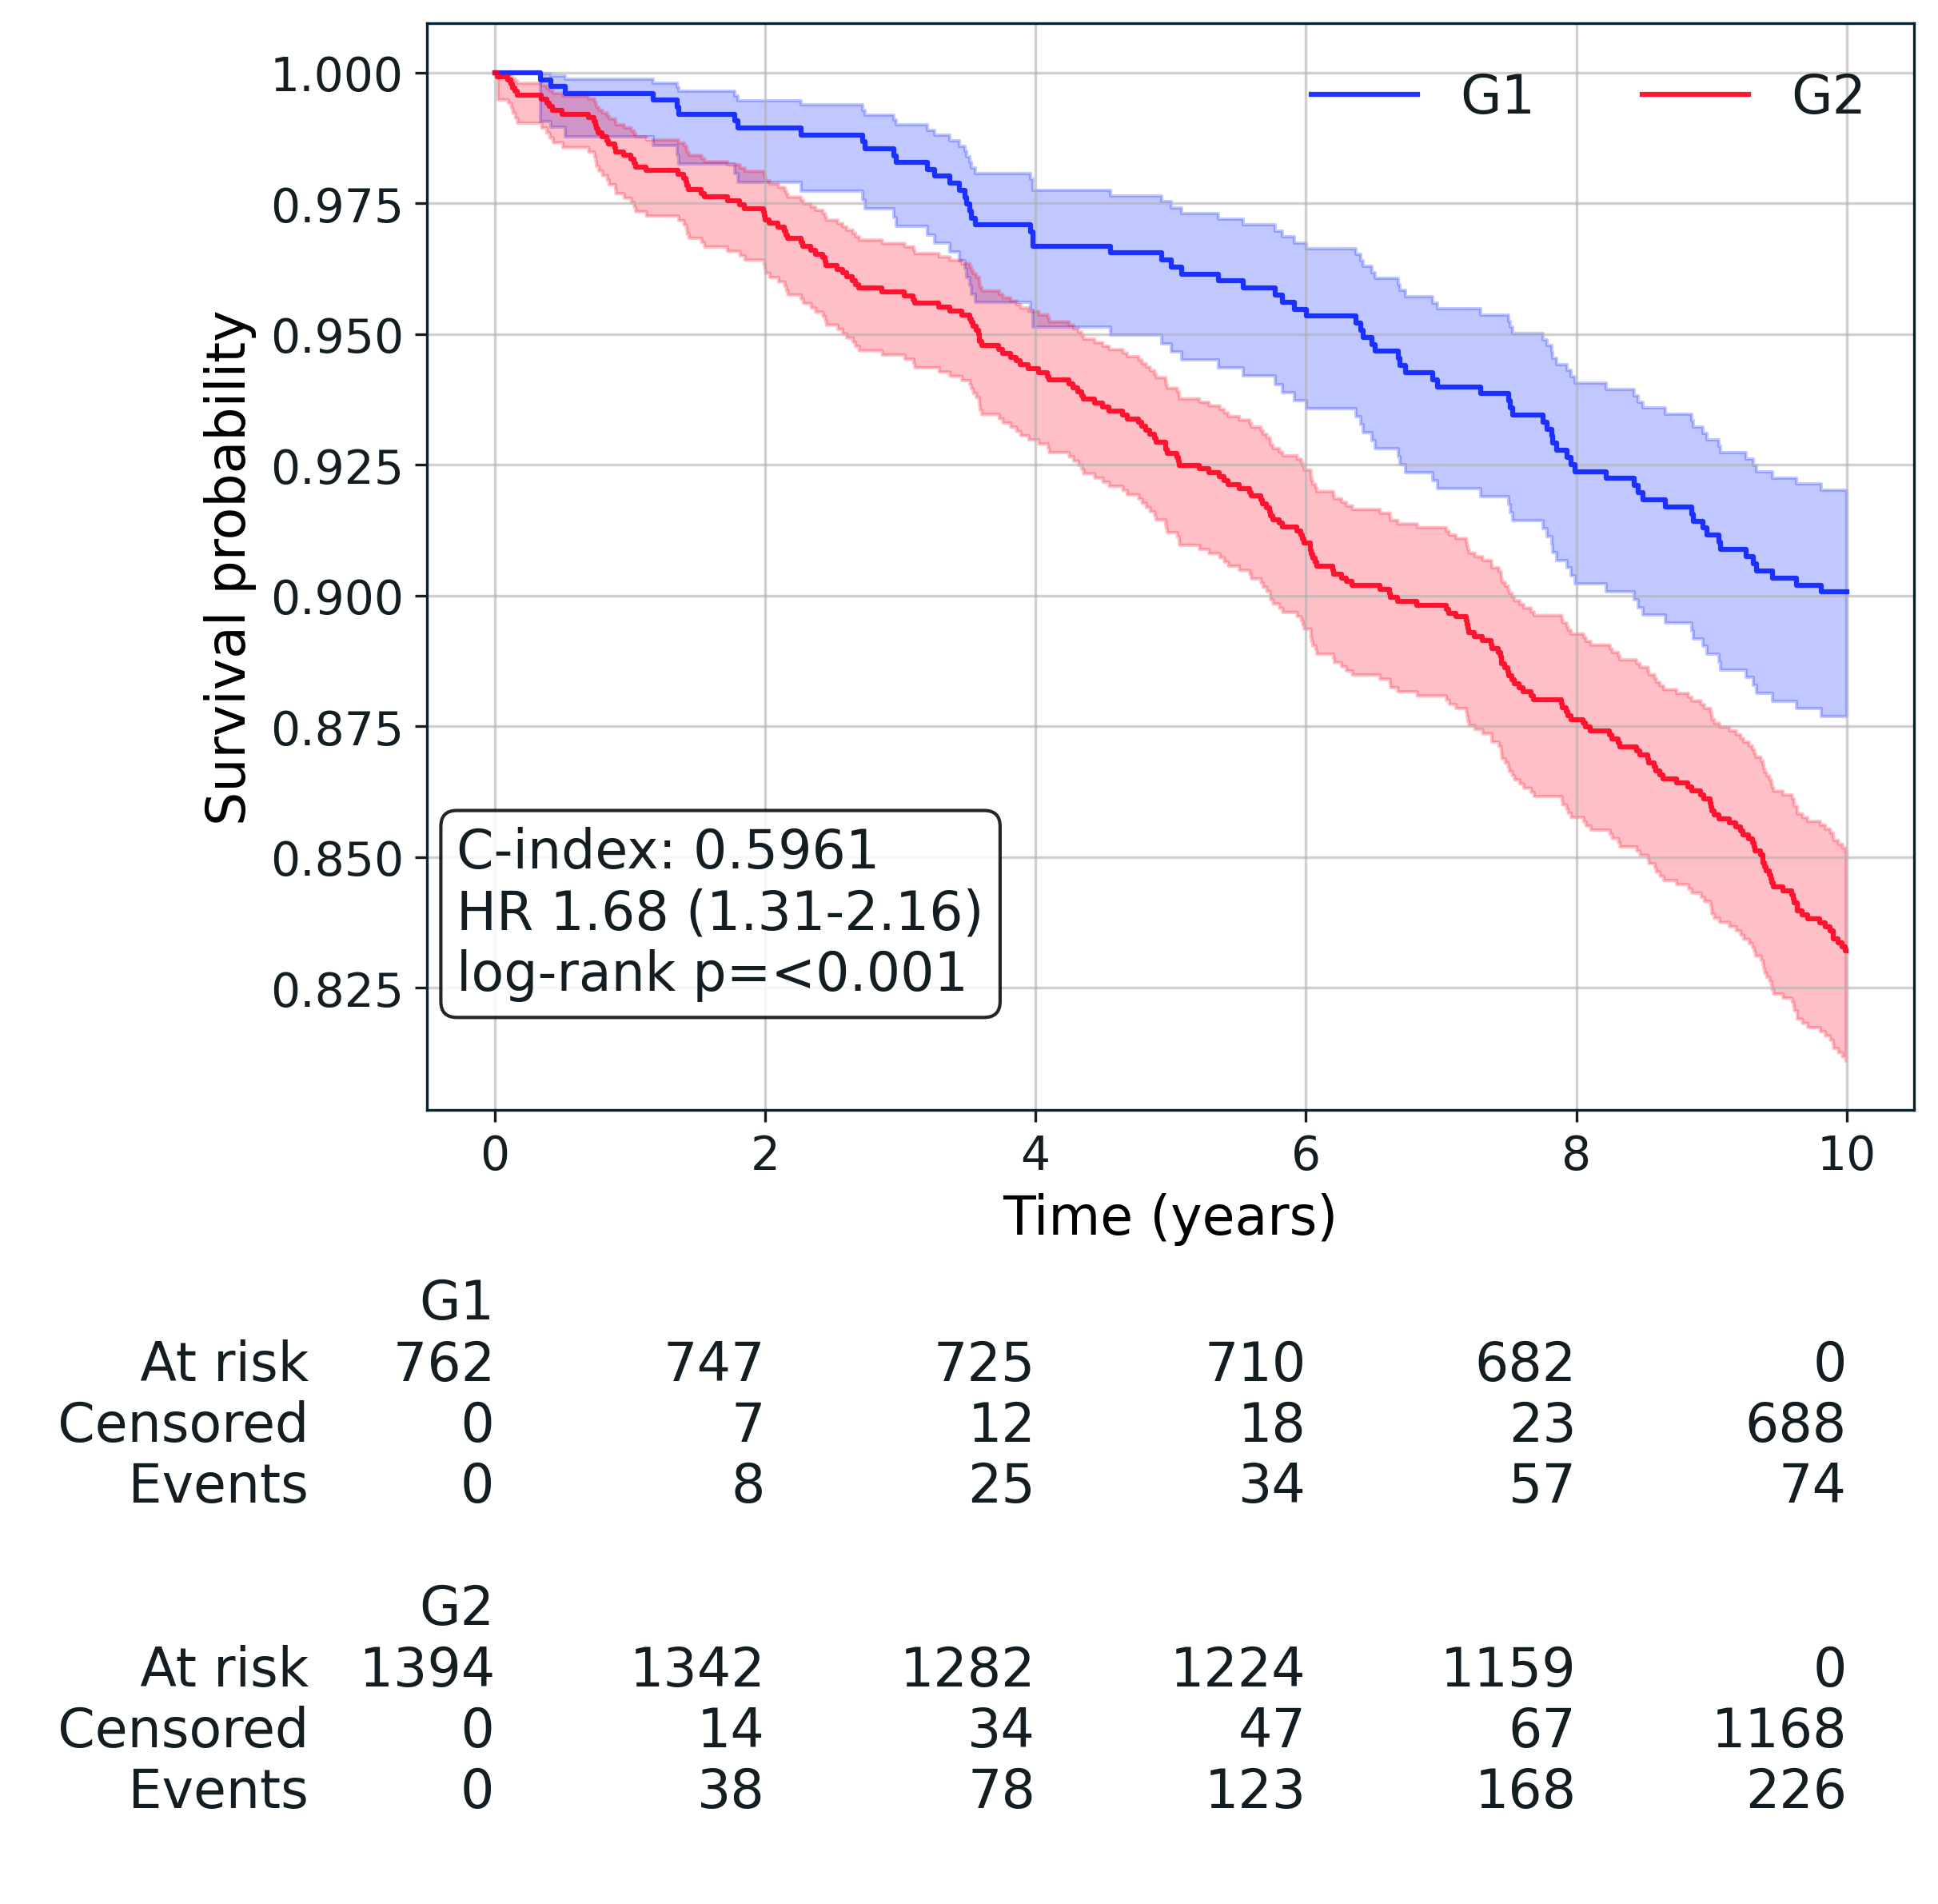

In [33]:
col_list = mmace_features

temp_train_df = main_cohort_dict["D3_mmace"].copy().dropna(subset=col_list)
temp_test_df = main_cohort_dict["D1_mmace"].copy().dropna(subset=col_list)

outputs = train_cox_model(
    temp_train_df,
    temp_test_df,
    selected_features=col_list,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    verbose=True,
    plot_groups=[2],
    percentiles=[0, 0.8, 1],
    penalizer = 0.01
)
# plt.savefig(FIGURE_DIR + "kmcurve_snap.svg", dpi=300, bbox_inches="tight")

temp_train_df['MMACE_risk_score'] = outputs["train_df"]['risk_score']
temp_test_df['MMACE_risk_score'] = outputs["test_df"]['risk_score']


results = outputs["results"]

train_median_risk = temp_train_df['MMACE_risk_score'].median()
temp_train_df['MMACE_risk_score_group'] = temp_train_df['MMACE_risk_score'].apply(lambda x: 1 if x >= train_median_risk else 0)
temp_test_df['MMACE_risk_score_group'] = temp_test_df['MMACE_risk_score'].apply(lambda x: 1 if x >= train_median_risk else 0)

MMACE_D3train_df = temp_train_df.copy()
MMACE_D2test_df = temp_test_df.copy()

cori_train_df['MMACE_risk_score'] = MMACE_D2test_df['MMACE_risk_score']
cori_train_df['MMACE_risk_score_group'] = MMACE_D2test_df['MMACE_risk_score_group']

## adding for SHAP analysis
cori_model    = outputs["cox_model"]
cori_features = col_list  

print("Train: pval",  round(results['train']['p_value'], 4), "cindex", round(results['train']['c_index'], 4) )
print("Test: pval",  round(results['test']['p_value'], 4), "cindex", round(results['test']['c_index'], 4) )


 train shape: (14159, 1069)
 test shape: (2435, 1089)


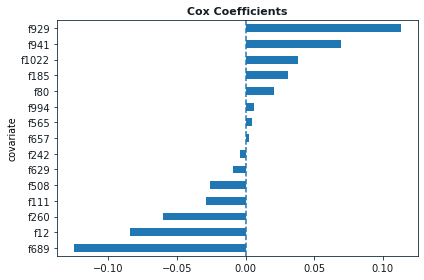

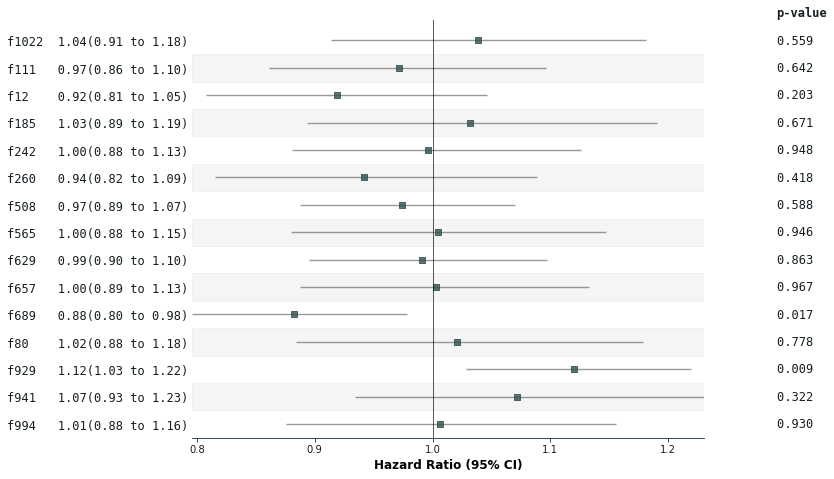

Using provided percentiles: [0, 0.8, 1]

Hazard Ratios (Train) -- each vs ref group
  High risk vs Low risk: HR = 2.486 (95% CI 2.234 - 2.766), p = 1.32e-62

Hazard Ratios (Test)  -- each vs ref group
  High risk vs Low risk: HR = 1.794 (95% CI 1.410 - 2.284), p = 2.03e-06
Train: pval 0.0 cindex 0.6154
Test: pval 0.0 cindex 0.6157


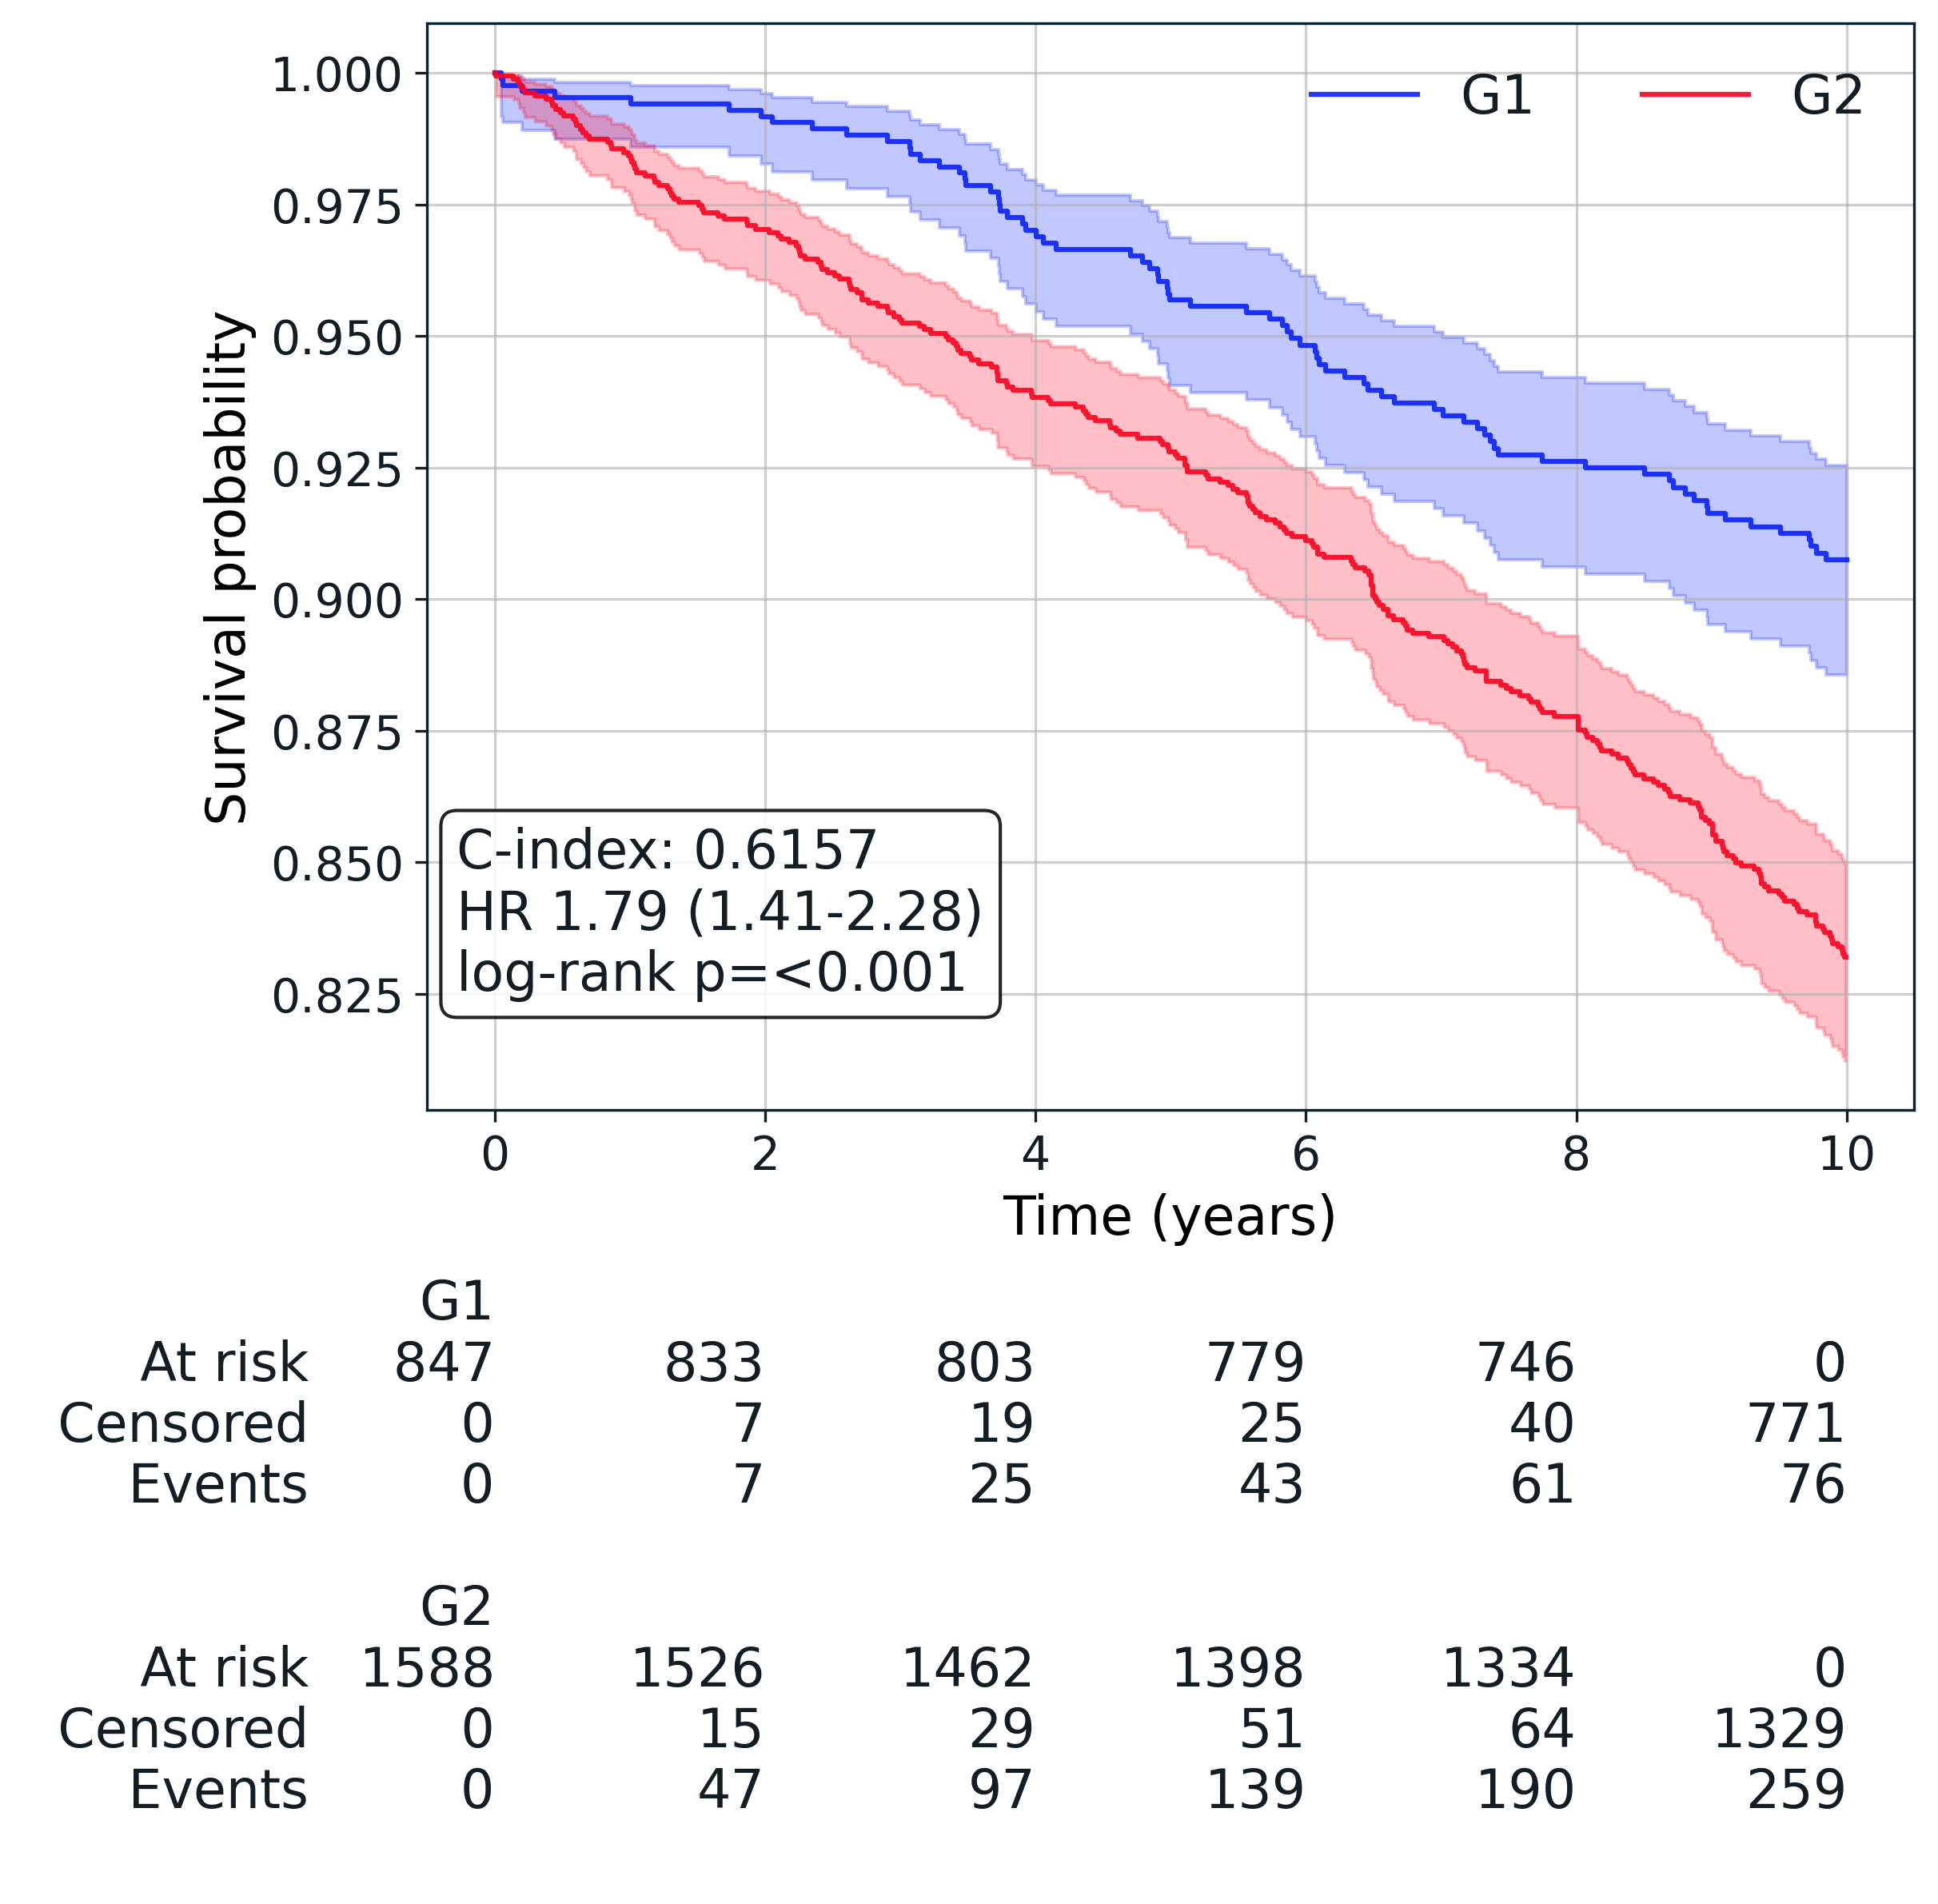

In [34]:
col_list = mmace_features

temp_train_df = main_cohort_dict["D3_mmace"].copy().dropna(subset=col_list)
temp_test_df = main_cohort_dict["D2_mmace"].copy().dropna(subset=col_list)

outputs = train_cox_model(
    temp_train_df,
    temp_test_df,
    selected_features=col_list,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    verbose=True,
    plot_groups=[2],
    percentiles=[0, 0.8, 1],
    penalizer = 0.01
)
# plt.savefig(FIGURE_DIR + "kmcurve_snap.svg", dpi=300, bbox_inches="tight")

temp_train_df['MMACE_risk_score'] = outputs["train_df"]['risk_score']
temp_test_df['MMACE_risk_score'] = outputs["test_df"]['risk_score']


results = outputs["results"]

train_median_risk = temp_train_df['MMACE_risk_score'].median()
temp_train_df['MMACE_risk_score_group'] = temp_train_df['MMACE_risk_score'].apply(lambda x: 1 if x >= train_median_risk else 0)
temp_test_df['MMACE_risk_score_group'] = temp_test_df['MMACE_risk_score'].apply(lambda x: 1 if x >= train_median_risk else 0)

MMACE_D3train_df = temp_train_df.copy()
MMACE_D2test_df = temp_test_df.copy()


 
cori_test_df['MMACE_risk_score'] = MMACE_D2test_df['MMACE_risk_score']
cori_test_df['MMACE_risk_score_group'] = MMACE_D2test_df['MMACE_risk_score_group']

## adding for SHAP analysis
cori_model    = outputs["cox_model"]
cori_features = col_list  

print("Train: pval",  round(results['train']['p_value'], 4), "cindex", round(results['train']['c_index'], 4) )
print("Test: pval",  round(results['test']['p_value'], 4), "cindex", round(results['test']['c_index'], 4) )


# Joint model

## CORI + MMACE model

In [35]:
col_list = ["CORI_risk_score", "MMACE_risk_score",]

cori_train_df[col_list].describe()

,CORI_risk_score,MMACE_risk_score
count,2.156000e+03,2.156000e+03
mean,-1.318261e-17,5.602610e-17
std,1.000000e+00,1.000000e+00
min,-2.768326e+00,-5.779527e+00
25%,-6.948475e-01,-5.816425e-01
50%,-1.498704e-02,7.950538e-02
75%,6.657004e-01,7.255827e-01
max,3.196866e+00,2.298386e+00


 train shape: (2156, 1093)
 test shape: (2435, 1093)


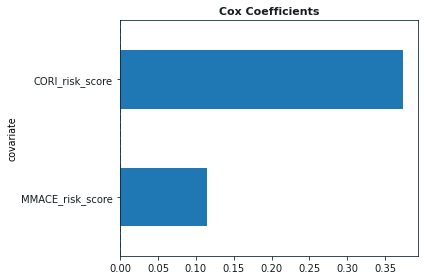

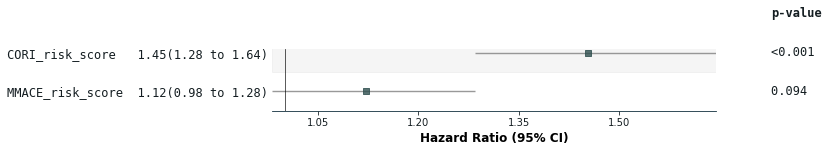

Using provided percentiles: [0, 0.8, 1]

Hazard Ratios (Train) -- each vs ref group
  High risk vs Low risk: HR = 1.762 (95% CI 1.382 - 2.246), p = 4.78e-06

Hazard Ratios (Test)  -- each vs ref group
  High risk vs Low risk: HR = 1.937 (95% CI 1.548 - 2.424), p = 7.27e-09
Train: pval 0.0 cindex 0.6325
Test: pval 0.0 cindex 0.6198


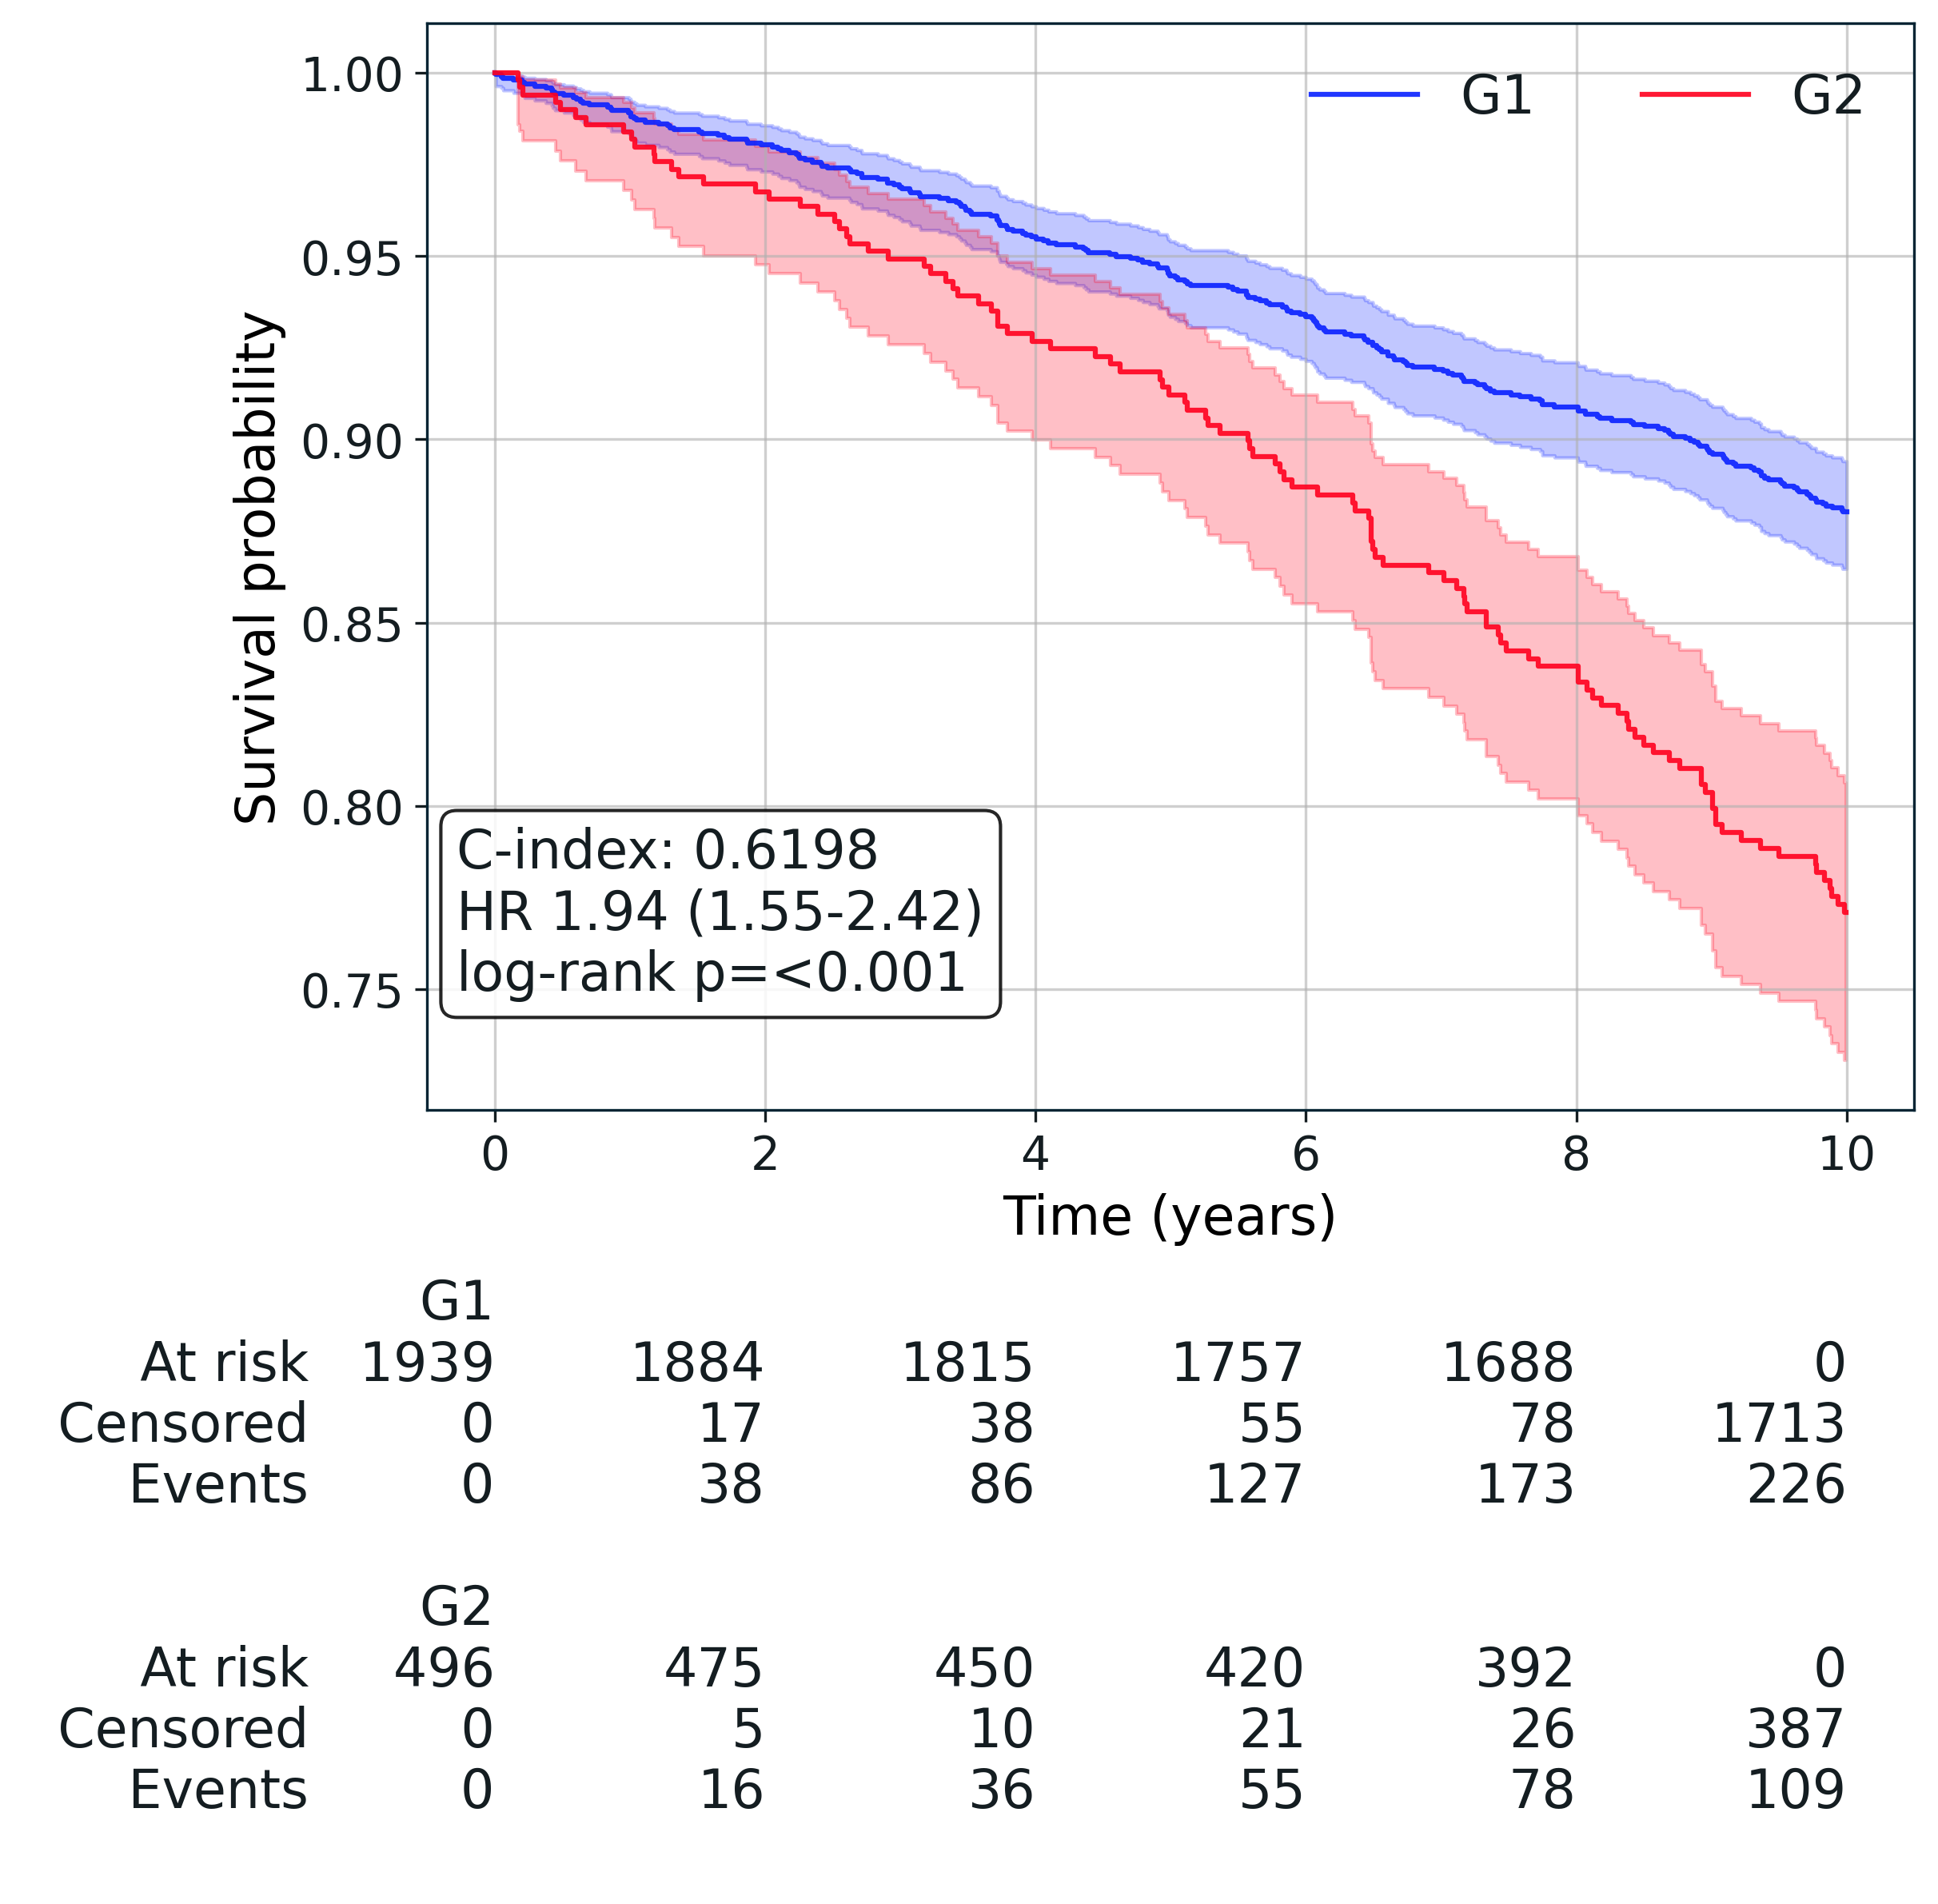

In [38]:
col_list = ["CORI_risk_score", "MMACE_risk_score",]

temp_train_df = cori_train_df.copy().dropna(subset=col_list)
temp_test_df = cori_test_df.copy().dropna(subset=col_list)

outputs = train_cox_model(
    temp_train_df,
    temp_test_df,
    selected_features=col_list,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    verbose=True,
    plot_groups=[2],
    percentiles=[0, 0.8, 1],
    penalizer=0.01
)
# plt.savefig(FIGURE_DIR + "kmcurve_snap.svg", dpi=300, bbox_inches="tight")

temp_train_df['MMACE_risk_score'] = outputs["train_df"]['risk_score']
temp_test_df['MMACE_risk_score'] = outputs["test_df"]['risk_score']

results = outputs["results"]

train_median_risk = temp_train_df['MMACE_risk_score'].median()
temp_train_df['MMACE_risk_score_group'] = temp_train_df['MMACE_risk_score'].apply(lambda x: 1 if x >= train_median_risk else 0)
temp_test_df['MMACE_risk_score_group'] = temp_test_df['MMACE_risk_score'].apply(lambda x: 1 if x >= train_median_risk else 0)

 
# cori_test_df['MMACE_risk_score'] = MMACE_D2test_df['MMACE_risk_score']
# cori_test_df['MMACE_risk_score_group'] = MMACE_D2test_df['MMACE_risk_score_group']

# ## adding for SHAP analysis
# cori_model    = outputs["cox_model"]
# cori_features = col_list  

print("Train: pval",  round(results['train']['p_value'], 4), "cindex", round(results['train']['c_index'], 4) )
print("Test: pval",  round(results['test']['p_value'], 4), "cindex", round(results['test']['c_index'], 4) )


# Multivariable analysis

## CORI + MMACE on D2

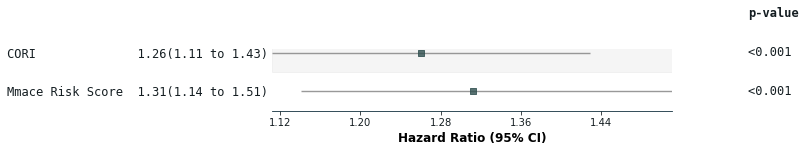

In [41]:
from src2.train import do_multivar
 
# convert categiracal to numerical for center 
cori_test_df['center_intLabel'] = cori_test_df['center'].astype('category').cat.codes
cori_test_df['center_intLabel'].value_counts()

multivar_cols =  [   
                'CORI_risk_score',  'MMACE_risk_score']

temp_test_df = cori_test_df.copy()[multivar_cols + [time_col, event_col]].dropna().reset_index(drop=True)

forest_df = do_multivar(
    temp_test_df,
    multivar_cols,
    time_col=time_col,
    event_col=event_col,
    label_map=label_map,
    verbose=True
)
# plt.savefig(FIGURE_DIR + "forestplot_multivar_snap_heart.svg", dpi=300, bbox_inches="tight")

# save as final_common_risk_risk_score.csv
# temp_train_df.to_csv(os.path.join(save_dir, "train_SNAP+clinical.csv"), index=False)
# temp_test_df.to_csv(os.path.join(save_dir, "test_SNAP+clinical.csv"), index=False)


## CORI + MMACE + Clinical on D2

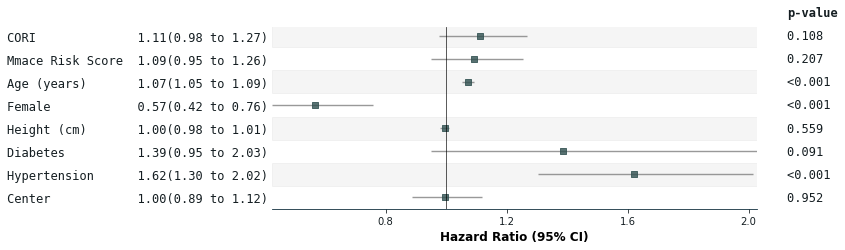

In [50]:
from src2.train import do_multivar
 
# convert categiracal to numerical for center 
cori_test_df['center_intLabel'] = cori_test_df['center'].astype('category').cat.codes
cori_test_df['center_intLabel'].value_counts()

multivar_cols =  [ 'CORI_risk_score',  'MMACE_risk_score', 'age', 'female', 'height', "Diabetes", "HTN",
                "center_intLabel"]

temp_test_df = cori_test_df.copy()[multivar_cols + [time_col, event_col]].dropna().reset_index(drop=True)

forest_df = do_multivar(
    temp_test_df,
    multivar_cols,
    time_col=time_col,
    event_col=event_col,
    label_map=label_map,
    verbose=True
)
# plt.savefig(FIGURE_DIR + "forestplot_multivar_snap_heart.svg", dpi=300, bbox_inches="tight")

# save as final_common_risk_risk_score.csv
# temp_train_df.to_csv(os.path.join(save_dir, "train_SNAP+clinical.csv"), index=False)
# temp_test_df.to_csv(os.path.join(save_dir, "test_SNAP+clinical.csv"), index=False)


## CORI + Clinical on D2

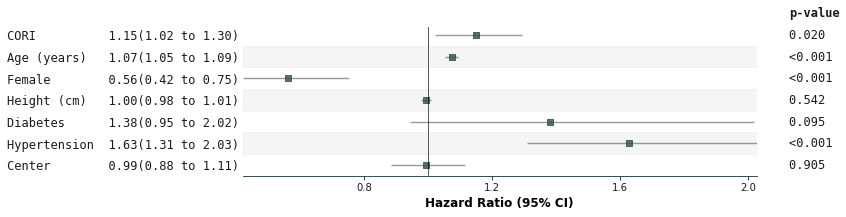

In [42]:
 
# convert categiracal to numerical for center 
cori_test_df['center_intLabel'] = cori_test_df['center'].astype('category').cat.codes
cori_test_df['center_intLabel'].value_counts()

multivar_cols =  [   
                'CORI_risk_score', 'age', 'female', 'height', "Diabetes", "HTN",
                "center_intLabel"]

temp_test_df = cori_test_df.copy()[multivar_cols + [time_col, event_col]].dropna().reset_index(drop=True)

forest_df = do_multivar(
    temp_test_df,
    multivar_cols,
    time_col=time_col,
    event_col=event_col,
    label_map=label_map,
    verbose=True
)
# plt.savefig(FIGURE_DIR + "forestplot_multivar_snap_heart.svg", dpi=300, bbox_inches="tight")

# save as final_common_risk_risk_score.csv
# temp_train_df.to_csv(os.path.join(save_dir, "train_SNAP+clinical.csv"), index=False)
# temp_test_df.to_csv(os.path.join(save_dir, "test_SNAP+clinical.csv"), index=False)


# Subgroup analysis

## Clinical variables based subgroup

Age, sex, treatment, and cancer-site subgroup analyses

,subgroup,level,N,events,HR,HR_low,HR_high,p,adjusted_for,dropped_constant,forest_label
0,age_group,Age <60,1223,87,1.141498,0.910495,1.431111,0.251312,"age, female, Diabetes, HTN",,Age: Age <60
1,age_group,Age ≥60,1212,248,1.138511,0.989168,1.310402,0.070581,"age, female, Diabetes, HTN",,Age: Age ≥60
2,cancer_site,BreastCancer,368,46,1.385280,0.996385,1.925963,0.052572,NaN,,Cancer site: BreastCancer
3,cancer_site,DigestiveCancer,162,38,0.951999,0.661266,1.370556,0.791338,NaN,,Cancer site: DigestiveCancer
4,cancer_site,HeamatoCancer,109,26,1.121602,0.757470,1.660782,0.566641,NaN,,Cancer site: HeamatoCancer
5,cancer_site,InsituCancer,170,21,1.463836,0.923722,2.319761,0.104762,NaN,,Cancer site: InsituCancer
6,cancer_site,MaleRepoCancer,165,40,1.207566,0.828803,1.759424,0.326024,NaN,female,Cancer site: MaleRepoCancer
7,cancer_site,SecondaryCancer,275,51,1.252900,0.876550,1.790838,0.216076,NaN,,Cancer site: SecondaryCancer
8,cancer_site,SkinCancer,376,72,1.186926,0.918504,1.533790,0.190170,NaN,,Cancer site: SkinCancer
9,sex_group,Female,1641,172,1.188907,1.012206,1.396456,0.035053,"age, Diabetes, HTN",female,Sex: Female


/mnt/c/Users/ap4si/OneDrive - Emory/Data/Shared_data/people/Dharini_Raghavan/CORI/CORI_dev_code/outputs_refactored/tables/Table_12_subgroup_CORI_associations.csv


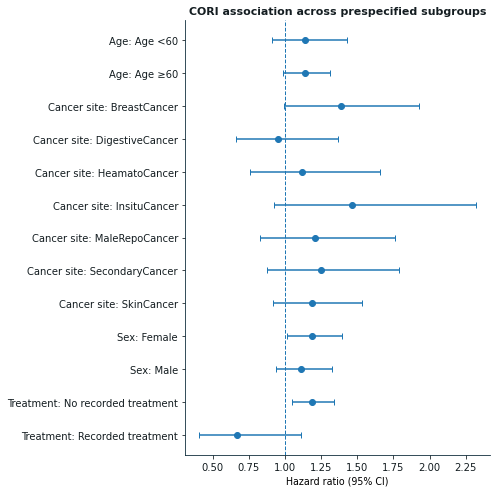

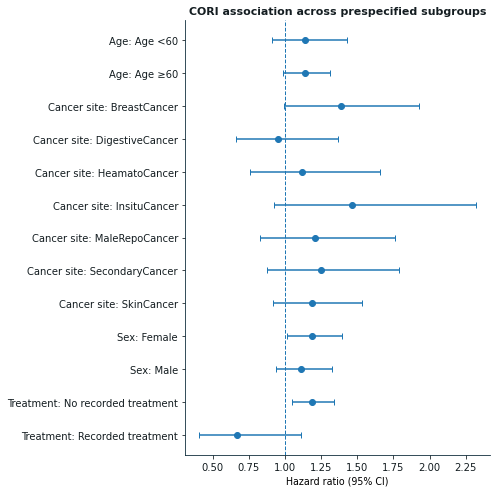

In [54]:
# ============================================================
# Prespecified CORI subgroup associations in held-out D2
# ============================================================

d2_subgroups = cori_test_df.copy()

d2_subgroups["age_group"] = np.where(
    d2_subgroups["age"] < 60,
    "Age <60",
    "Age ≥60",
)

d2_subgroups["sex_group"] = np.where(
    d2_subgroups["female"] == 1,
    "Female",
    "Male",
)

d2_subgroups["treatment_group"] = np.where(
    d2_subgroups["any_treatment"] == 1,
    "Recorded treatment",
    "No recorded treatment",
)


# ------------------------------------------------------------
# Age, sex, and recorded-treatment subgroups
# ------------------------------------------------------------

subgroup_tables = [
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_risk_score",
        subgroup_column="age_group",
        minimum_events=20,
        covariates=PRIMARY_ADJUSTMENT,
    ),
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_risk_score",
        subgroup_column="sex_group",
        minimum_events=20,
        covariates=PRIMARY_ADJUSTMENT,
    ),
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_risk_score",
        subgroup_column="treatment_group",
        minimum_events=15,
        covariates=PRIMARY_ADJUSTMENT,
    ),
]


# ------------------------------------------------------------
# Cancer-site subgroups
# ------------------------------------------------------------

for site in CANCER_SITE_COLUMNS:
    if site not in d2_subgroups.columns:
        continue

    site_data = d2_subgroups.loc[
        d2_subgroups[site]
        .fillna(0)
        .astype(int)
        .eq(1)
    ].copy()

    events = int(site_data["Y_mace"].sum())

    if events < 20:
        continue

    summary, _ = adjusted_cox(
        site_data,
        score_column="CORI_risk_score",
        covariates=PRIMARY_ADJUSTMENT,
        penalizer=0.01,
    )

    score_row = summary.loc[
        summary["term"] == "CORI_risk_score"
    ].iloc[0]

    subgroup_tables.append(
        pd.DataFrame(
            [
                {
                    "subgroup": "cancer_site",
                    "level": site.replace(
                        "_present",
                        "",
                    ),
                    "N": int(score_row["N"]),
                    "events": int(
                        score_row["events"]
                    ),
                    "HR": score_row["HR"],
                    "HR_low": score_row["HR_low"],
                    "HR_high": score_row["HR_high"],
                    "p": score_row["p"],
                    "dropped_constant": (
                        score_row[
                            "dropped_constant"
                        ]
                    ),
                }
            ]
        )
    )


# ------------------------------------------------------------
# Combine and save
# ------------------------------------------------------------

subgroup_tables = [
    table
    for table in subgroup_tables
    if table is not None
    and not table.empty
]

subgroups = pd.concat(
    subgroup_tables,
    ignore_index=True,
)

subgroup_labels = {
    "age_group": "Age",
    "sex_group": "Sex",
    "treatment_group": "Treatment",
    "cancer_site": "Cancer site",
}

subgroups["forest_label"] = (
    subgroups["subgroup"]
    .map(subgroup_labels)
    .fillna(subgroups["subgroup"])
    + ": "
    + subgroups["level"].astype(str)
)

subgroups = (
    subgroups
    .sort_values(
        ["subgroup", "level"]
    )
    .reset_index(drop=True)
)

display(subgroups)

save_table(
    subgroups,
    "Table_12_subgroup_CORI_associations",
)


# ------------------------------------------------------------
# Forest plot
# The keyword names must match src/plots.py exactly.
# ------------------------------------------------------------

forest_plot(
    df=subgroups,
    label="forest_label",
    estimate="HR",
    lower="HR_low",
    upper="HR_high",
    title=(
        "CORI association across "
        "prespecified subgroups"
    ),
    path=(
        FIGURE_DIR
        / "Figure_S_subgroup_forest"
    ),
)

## Treatment based subgroup

In [ ]:
 

# Supplementary Figure 2. Treatment analyses

treatment_strata = read_csv(TABLE_DIR / "Table_11A_treatment_stratified_CORI.csv")
treatment_interactions = read_csv(TABLE_DIR / "Table_11C_treatment_by_CORI_interactions.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.2), layout="constrained")

ts = treatment_strata.iloc[::-1].reset_index(drop=True)
y = np.arange(len(ts))
ax1.errorbar(ts["HR"], y, xerr=[ts["HR"]-ts["HR_low"], ts["HR_high"]-ts["HR"]],
             fmt="none", ecolor=CORI, capsize=3, elinewidth=1.7)
ax1.scatter(ts["HR"], y, color=CORI, s=50)
ax1.axvline(1, color=GRAY, linestyle="--")
ax1.set_yticks(y, ts.apply(lambda r: f"{r['cohort']} (N={int(r['N']):,}; E={int(r['events'])})", axis=1))
ax1.set_xscale("log")
ax1.set_xlim(0.4, 5.2)
ax1.set_xlabel("High- versus low-CORI HR")
ax1.set_title("Treatment-stratified CORI performance")
clean_axes(ax1, "x")
panel_letter(ax1, "A")

interaction_labels = {
    "has_target_drug": "Any systemic treatment",
    "has_chemo": "Chemotherapy",
    "has_io": "Immunotherapy",
    "any_treatment": "Any recorded treatment",
}
ti = treatment_interactions.copy()
ti["label"] = ti["treatment"].map(interaction_labels).fillna(ti["treatment"])
ti = ti.drop_duplicates("label").iloc[::-1].reset_index(drop=True)
y = np.arange(len(ti))
ax2.errorbar(ti["HR"], y, xerr=[ti["HR"]-ti["HR_low"], ti["HR_high"]-ti["HR"]],
             fmt="none", ecolor=MMACE, capsize=3, elinewidth=1.7)
ax2.scatter(ti["HR"], y, color=MMACE, s=50)
ax2.axvline(1, color=GRAY, linestyle="--")
ax2.set_yticks(y, ti["label"])
ax2.set_xscale("log")
ax2.set_xlim(0.25, 3.0)
ax2.set_xlabel("Treatment × CORI interaction HR")
ax2.set_title("Treatment interaction")
clean_axes(ax2, "x")
for yi, row in enumerate(ti.itertuples()):
    ax2.text(3.05, yi, p_text(row.p), va="center", fontsize=8, clip_on=False)
panel_letter(ax2, "B")

save_figure(fig, "Supplementary_Figure2_treatment")
plt.show()


In [ ]:
treatment_rows = []
for value, label in [(0, "No recorded systemic treatment"), (1, "Any recorded systemic treatment")]:
    subset = main_cohort_dict["D2_cori"].loc[main_cohort_dict["D2_cori"]["any_treatment"] == value]
    if subset["Y_mace"].sum() >= 5:
        treatment_rows.append(performance_row(subset, label, "CORI_z", "CORI_high", 500))
treatment_performance = pd.DataFrame(treatment_rows)
# save_table(treatment_performance, "Table_11A_treatment_stratified_CORI")

adjusted_treatment, _ = adjusted_cox(
    main_cohort_dict["D2_cori"], "CORI_z", [*TREATMENT_COLUMNS, *PRIMARY_ADJUSTMENT]
)
# save_table(adjusted_treatment, "Table_11B_treatment_adjusted_CORI")

interaction_rows = []
for treatment_column in [*TREATMENT_COLUMNS, "any_treatment"]:
    summary, _ = adjusted_cox(
        main_cohort_dict["D2_cori"], "CORI_z", PRIMARY_ADJUSTMENT,
        interaction_column=treatment_column,
    )
    interaction_term = f"CORI_z_x_{treatment_column}"
    row = summary.loc[summary["term"] == interaction_term].iloc[0].to_dict()
    row["treatment"] = treatment_column
    interaction_rows.append(row)
# save_table(pd.DataFrame(interaction_rows), "Table_11C_treatment_by_CORI_interactions")

## Center based subgroup

In [ ]:
center_data = main_cohort_dict["D2_cori"].copy()
center_data["reporting_center"] = center_data["center"].replace({"Liverpool": "Liverpool + Swansea", "Swansea": "Liverpool + Swansea"})
center_rows = []
for center, subset in center_data.groupby("reporting_center"):
    if subset["Y_mace"].sum() >= 5:
        center_rows.append(performance_row(subset, center, "CORI_z", "CORI_high", 500))
center_table = pd.DataFrame(center_rows)
save_table(center_table, "Table_07_center_level_CORI_performance")
forest_plot(center_table, "cohort", "HR", "HR_low", "HR_high", "CORI high versus low by center", FIGURE_DIR / "Figure_S_center_forest")

In [ ]:

# B. Cancer-type CORI forest
ax_b = fig.add_subplot(gs[0, 1])
sg = subtypes.copy()
sg["label"] = sg.apply(
    lambda row: f"{row['cancer_type']}  (N={int(row['N']):,}; E={int(row['events'])})",
    axis=1,
)
sg = sg.iloc[::-1].reset_index(drop=True)
y = np.arange(len(sg))
xmax = 8.0
for yi, row in enumerate(sg.itertuples()):
    low = max(row.CORI_CI_low, 0.05)
    high = min(row.CORI_CI_high, xmax)
    color = CORI if row.cancer_type == "All cancer" else (CORAL if row.CORI_p < 0.05 else GRAY_MID)
    ax_b.plot([low, high], [yi, yi], color=color, linewidth=1.5)
    ax_b.scatter(row.CORI_HR_per_SD, yi, s=42, color=color, edgecolor=WHITE, linewidth=0.6, zorder=3)
    if row.CORI_CI_high > xmax:
        ax_b.annotate("", xy=(xmax, yi), xytext=(xmax*0.90, yi),
                      arrowprops=dict(arrowstyle="-|>", color=color, lw=1.3))
ax_b.axvline(1, color=GRAY, linestyle="--", linewidth=1)
ax_b.set_xscale("log")
ax_b.set_xlim(0.25, xmax)
ax_b.set_yticks(y, sg["label"])
ax_b.set_xlabel("Adjusted CORI hazard ratio per 1 SD (95% CI)")
ax_b.set_title("CORI association across major cancer groups", pad=10)
clean_axes(ax_b, "x")
for yi, row in enumerate(sg.itertuples()):
    ax_b.text(
        xmax * 1.04, yi,
        f"{row.CORI_HR_per_SD:.2f} ({row.CORI_CI_low:.2f}–{row.CORI_CI_high:.2f})\n{p_text(row.CORI_p)}",
        ha="left", va="center", fontsize=7.8, clip_on=False,
        color=CORI_DARK if row.cancer_type == "All cancer" else BLACK,
        fontweight="bold" if row.cancer_type == "All cancer" else "normal",
    )
panel_letter(ax_b, "B")

fw.to_csv(SOURCE_DIR / "Figure5_fourway_components.csv", index=False)
sg.to_csv(SOURCE_DIR / "Figure5_cancer_subtypes.csv", index=False)

save_figure(fig, "Figure5_fourway_and_cancer_subtypes")
plt.show()

In [ ]:

# Supplementary Figure 1. Center-level validation

center = read_csv(TABLE_DIR / "Table_07_center_level_CORI_performance.csv").iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7.5, 3.8), layout="constrained")
y = np.arange(len(center))
ax.errorbar(
    center["HR"], y,
    xerr=[center["HR"] - center["HR_low"], center["HR_high"] - center["HR"]],
    fmt="none", ecolor=CORI, elinewidth=1.8, capsize=3,
)
ax.scatter(center["HR"], y, color=CORI, s=50, zorder=3)
ax.axvline(1, color=GRAY, linestyle="--")
ax.set_yticks(y, center.apply(lambda r: f"{r['cohort']} (N={int(r['N']):,}; E={int(r['events'])})", axis=1))
ax.set_xscale("log")
ax.set_xlim(0.8, 5.0)
ax.set_xlabel("High- versus low-CORI hazard ratio (95% CI)")
ax.set_title("Center-level CORI validation")
clean_axes(ax, "x")
for yi, row in enumerate(center.itertuples()):
    ax.text(5.1, yi, f"{row.HR:.2f} ({row.HR_low:.2f}–{row.HR_high:.2f})",
            va="center", fontsize=8, clip_on=False)
save_figure(fig, "Supplementary_Figure1_center_validation")
plt.show()

# Reclassification

In [ ]:

# B. Clinical × CORI matrix
ax_b = fig.add_subplot(gs[0, 1])
order = ["Low", "Middle", "High"]
counts = clinical_counts.set_index("Clinical_risk_tertile").loc[order, order]
rates = clinical_rates.set_index("Clinical_risk_tertile").loc[order, order] * 100
cmap = LinearSegmentedColormap.from_list("event_rate", [WHITE, CORAL_LIGHT, CORAL])
image = ax_b.imshow(rates.values, cmap=cmap, vmin=0, vmax=max(30, rates.to_numpy().max()))
for i in range(3):
    for j in range(3):
        value = rates.iloc[i, j]
        color = WHITE if value > 20 else BLACK
        ax_b.text(j, i, f"N={int(counts.iloc[i,j]):,}\n{value:.1f}% MACE",
                  ha="center", va="center", fontsize=8.7, color=color,
                  fontweight="bold" if value > 20 else "normal")
ax_b.set_xticks(range(3), ["Low", "Intermediate", "High"])
ax_b.set_yticks(range(3), ["Low", "Intermediate", "High"])
ax_b.set_xlabel("CORI tertile")
ax_b.set_ylabel("Clinical-risk tertile")
ax_b.set_title("CORI enrichment within clinical risk", pad=10)
for edge in np.arange(-0.5, 3, 1):
    ax_b.axhline(edge, color=WHITE, linewidth=2)
    ax_b.axvline(edge, color=WHITE, linewidth=2)
colorbar = fig.colorbar(image, ax=ax_b, fraction=0.045, pad=0.03)
colorbar.set_label("Observed 10-year MACE, %")
panel_letter(ax_b, "B")


In [ ]:

# Figure 3. CORI versus MMACE

fig = plt.figure(figsize=(16.5, 5.8), layout="constrained")
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.10, 1.15])

# A. Cross-domain performance
ax_a = fig.add_subplot(gs[0, 0])
model_map = {
    "CORI locked": "CORI",
    "MMACE equal complexity": "Equal-complexity MMACE",
    "MMACE practical": "Practical MMACE",
}
perf = cross_domain[
    cross_domain["cohort"].isin(["D2", "D4"])
    & cross_domain["model"].isin(model_map)
].copy()
perf["label"] = perf["model"].map(model_map)

model_order = ["CORI", "Equal-complexity MMACE", "Practical MMACE"]
model_colors = {"CORI": CORI, "Equal-complexity MMACE": MMACE_MID, "Practical MMACE": MMACE_DARK}
model_y = {label: i for i, label in enumerate(model_order[::-1])}
offset = {"D2": 0.10, "D4": -0.10}
marker = {"D2": "o", "D4": "D"}

for row in perf.itertuples():
    yval = model_y[row.label] + offset[row.cohort]
    ax_a.scatter(row.C_index, yval, s=60, color=model_colors[row.label],
                 marker=marker[row.cohort], edgecolor=WHITE, linewidth=0.8, zorder=3)
    ax_a.text(row.C_index + 0.002, yval, f"{row.C_index:.3f}", va="center", fontsize=8)

ax_a.axvline(0.5, color=GRAY, linestyle="--", linewidth=1)
ax_a.set_yticks(range(3), model_order[::-1])
ax_a.set_xlim(0.59, 0.675)
ax_a.set_xlabel("C-index")
ax_a.set_title("Cross-domain discrimination", pad=10)
clean_axes(ax_a, "x")
legend = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=GRAY_DARK, label="Cancer held-out (D2)", markersize=7),
    Line2D([0], [0], marker="D", color="none", markerfacecolor=GRAY_DARK, label="Never-cancer held-out (D4)", markersize=6),
]
ax_a.legend(handles=legend, frameon=False, loc="lower right", fontsize=8)
panel_letter(ax_a, "A")

# B. Equal MMACE × CORI event-rate matrix
ax_b = fig.add_subplot(gs[0, 1])
order = ["Low", "Middle", "High"]
counts = mmace_counts.set_index("MMACE_equal_tertile").loc[order, order]
rates = mmace_rates.set_index("MMACE_equal_tertile").loc[order, order] * 100
cmap = LinearSegmentedColormap.from_list("event_rate2", [WHITE, MMACE_LIGHT, CORAL])
image = ax_b.imshow(rates.values, cmap=cmap, vmin=0, vmax=max(25, rates.to_numpy().max()))
for i in range(3):
    for j in range(3):
        value = rates.iloc[i, j]
        color = WHITE if value > 18 else BLACK
        ax_b.text(j, i, f"N={int(counts.iloc[i,j]):,}\n{value:.1f}% MACE",
                  ha="center", va="center", fontsize=8.6, color=color)
ax_b.set_xticks(range(3), ["Low", "Intermediate", "High"])
ax_b.set_yticks(range(3), ["Low", "Intermediate", "High"])
ax_b.set_xlabel("CORI tertile")
ax_b.set_ylabel("Equal-complexity MMACE tertile")
ax_b.set_title("CORI enrichment within generic retinal risk", pad=10)
for edge in np.arange(-0.5, 3, 1):
    ax_b.axhline(edge, color=WHITE, linewidth=2)
    ax_b.axvline(edge, color=WHITE, linewidth=2)
colorbar = fig.colorbar(image, ax=ax_b, fraction=0.045, pad=0.03)
colorbar.set_label("Observed 10-year MACE, %")
panel_letter(ax_b, "B")

# C. Residual CORI beyond MMACE
ax_c = fig.add_subplot(gs[0, 2])
residual = residual_results.copy()
residual["label"] = residual["comparator"].replace(
    {
        "Equal-complexity MMACE": "Beyond equal-complexity MMACE",
        "Independently tuned MMACE": "Beyond tuned MMACE",
        "Practical MMACE": "Beyond practical MMACE",
    }
)
residual = residual.iloc[::-1].reset_index(drop=True)
y = np.arange(len(residual))
colors = [CORI, GRAY_MID, CORAL]
for yi, row in enumerate(residual.itertuples()):
    color = colors[yi]
    ax_c.errorbar(
        row.HR, yi,
        xerr=[[row.HR - row.HR_low], [row.HR_high - row.HR]],
        fmt="none", ecolor=color, elinewidth=1.7, capsize=3,
    )
    ax_c.scatter(row.HR, yi, s=50, color=color, zorder=3)
ax_c.axvline(1, color=GRAY, linestyle="--", linewidth=1)
ax_c.set_yticks(y, residual["label"])
ax_c.set_xlim(0.75, 1.85)
ax_c.set_xlabel("Residual CORI hazard ratio (95% CI)")
ax_c.set_title("Complementary CORI signal", pad=10)
clean_axes(ax_c, "x")
for yi, row in enumerate(residual.itertuples()):
    ax_c.text(1.87, yi, f"{row.HR:.2f} ({row.HR_low:.2f}–{row.HR_high:.2f})\n{p_text(row.p)}",
              ha="left", va="center", fontsize=8.1, clip_on=False)
panel_letter(ax_c, "C")

perf.to_csv(SOURCE_DIR / "Figure3_cross_domain_performance.csv", index=False)
mmace_counts.to_csv(SOURCE_DIR / "Figure3_MMACE_CORI_counts.csv", index=False)
mmace_rates.to_csv(SOURCE_DIR / "Figure3_MMACE_CORI_event_rates.csv", index=False)
residual.to_csv(SOURCE_DIR / "Figure3_residual_CORI.csv", index=False)

save_figure(fig, "Figure3_CORI_vs_MMACE")
plt.show()


# CORI - Clincial contri: Walds test

In [ ]:

# Supplementary Figure 5. Relative Wald contributions across cancer groups

wald = read_csv(ADDITIONAL_DIR / "Table_15_CORI_subtype_Wald_contributions.csv")
wald["term"] = wald["term"].replace(
    {"CORI_z": "CORI", "age": "Age", "female": "Sex", "height": "Height", "Diabetes": "Diabetes", "HTN": "Hypertension"}
)
order = subtypes["cancer_type"].tolist()
plot_table = (
    wald.pivot_table(index="cancer_type", columns="term", values="relative_wald_percent", aggfunc="sum")
    .fillna(0)
    .reindex(order)
)
column_order = [c for c in ["CORI", "Sex", "Age", "Diabetes", "Hypertension", "Height"] if c in plot_table]
plot_table = plot_table[column_order]

wald_colors = {
    "CORI": CORI,
    "Sex": GRAY_DARK,
    "Age": NAVY_MID,
    "Diabetes": MMACE,
    "Hypertension": CORAL,
    "Height": GRAY_MID,
}

fig, ax = plt.subplots(figsize=(10.5, 7.0), layout="constrained")
left = np.zeros(len(plot_table))
for column in plot_table.columns:
    values = plot_table[column].to_numpy()
    ax.barh(plot_table.index, values, left=left, label=column, color=wald_colors[column], height=0.68)
    left += values
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Relative Wald contribution, %")
ax.set_title("Relative model contribution across major cancer groups")
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.14))
clean_axes(ax, "x")
save_figure(fig, "Supplementary_Figure5_cancer_subtype_Wald_contributions")
plt.show()


# Feature overlap : CORI vs MMACE

# Cardiac MRI correlation

In [ ]:

# Figure 4. Biological anchoring

FEATURE_LABELS = {
    "HC_vessel_All_pixel_degree_3": "Global vessel branch-point density",
    "HC_vessel_All_STD_branch_distance": "Branch-spacing variability",
    "HC_vein_All_pixel_degree_3": "Venous branch-point density",
    "HC_vessel_All_STD_branch_length": "Branch-length variability",
    "HC_vessel_fundus_ring_75_125total_connected_pixels": "Inner peripheral connected vessel area",
    "HC_vein_All_total_connected_pixels": "Connected venous vessel area",
    "HC_vein_Allr_VD_binary": "Venous vessel density",
    "HC_vein_Allr_FD_binary": "Venous fractal dimension",
    "HC_vessel_fundus_ring_75_125pixel_degree_2": "Inner peripheral vessel connectivity",
    "HC_vessel_fundus_ring_125_175total_connected_pixels": "Outer peripheral connected vessel area",
}

CMR_LABELS = {
    "LV ejection fraction": "LV ejection fraction",
    "LV end diastolic volume": "LV end-diastolic volume",
    "LV end systolic volume": "LV end-systolic volume",
    "LV stroke volume": "LV stroke volume",
    "LV myocardial mass": "LV myocardial mass",
    "Central systolic blood pressure during PWA - PVR": "Central systolic pressure",
    "End systolic pressure during PWA - PVR": "End-systolic pressure",
    "Central pulse pressure during PWA - PVR": "Central pulse pressure",
    "Mean arterial pressure during PWA - PVR": "Mean arterial pressure",
    "Cardiac output during PWA - PVR": "Cardiac output",
    "Ascending aorta maximum area": "Ascending aorta maximum area",
    "Ascending aorta minimum area": "Ascending aorta minimum area",
    "Ascending aorta distensibility": "Ascending aorta distensibility",
    "Descending aorta maximum area": "Descending aorta maximum area",
    "Descending aorta minimum area": "Descending aorta minimum area",
    "Descending aorta distensibility": "Descending aorta distensibility",
}

fig = plt.figure(figsize=(17.5, 8.0), layout="constrained")
gs = fig.add_gridspec(1, 3, width_ratios=[1.20, 0.85, 1.60])

# A. Retinal descriptors
ax_a = fig.add_subplot(gs[0, 0])
retina = handcrafted.copy()
retina["label"] = retina["feature"].map(FEATURE_LABELS).fillna(retina["feature"])
retina = retina.sort_values("heldout_raw_rho").reset_index(drop=True)
y = np.arange(len(retina))
for yi, row in enumerate(retina.itertuples()):
    color = CORAL if row.heldout_raw_rho > 0 else CORI
    ax_a.plot([0, row.heldout_raw_rho], [yi, yi], color=color, linewidth=1.4, alpha=0.75)
    ax_a.scatter(row.heldout_raw_rho, yi, s=58, color=color, edgecolor=WHITE, linewidth=0.7, zorder=3)
    ax_a.scatter(row.heldout_partial_rho, yi, s=35, facecolor=WHITE, edgecolor=color, linewidth=1.3, zorder=4)
ax_a.axvline(0, color=GRAY, linestyle="--", linewidth=1)
ax_a.set_yticks(y, retina["label"])
ax_a.set_xlim(-0.46, 0.46)
ax_a.set_xlabel("Correlation with CORI")
ax_a.set_title("Retinal vascular descriptors", pad=10)
clean_axes(ax_a, "x")
ax_a.legend(
    handles=[
        Line2D([0], [0], marker="o", color="none", markerfacecolor=GRAY_DARK, label="Raw Spearman ρ", markersize=7),
        Line2D([0], [0], marker="o", color=GRAY_DARK, markerfacecolor=WHITE, label="Adjusted partial ρ", markersize=6),
    ],
    frameon=False, loc="lower right", fontsize=8,
)
panel_letter(ax_a, "A")

# B. CMR domain-level ACAT
ax_b = fig.add_subplot(gs[0, 1])
domains = cmr_domains.copy()
domains["label"] = domains["domain"].replace({"Central pressure / PWA": "Central pressure / PWA"})
domains["minus_log10_q"] = -np.log10(domains["q"])
domain_colors = [CORI, CORAL, MMACE]
bars = ax_b.barh(np.arange(len(domains)), domains["minus_log10_q"], color=domain_colors, height=0.58)
ax_b.axvline(-np.log10(0.05), color=GRAY_DARK, linestyle="--", linewidth=1)
ax_b.set_yticks(np.arange(len(domains)), domains["label"])
ax_b.invert_yaxis()
ax_b.set_xlabel("−log10(FDR q)")
ax_b.set_title("CMR domain evidence", pad=10)
clean_axes(ax_b, "x")
for bar, row in zip(bars, domains.itertuples()):
    ax_b.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height()/2,
        f"p={row.ACAT_p:.3f}\nq={row.q:.3f}",
        va="center", fontsize=8,
    )
global_p = float(domains["global_directional_ACAT_p"].iloc[0])
ax_b.text(
    0.03, 0.03,
    f"Global directional ACAT\np={global_p:.3f}",
    transform=ax_b.transAxes,
    fontsize=8.7,
    color=NAVY,
    bbox=dict(boxstyle="round,pad=0.3", facecolor=NAVY_LIGHT, edgecolor=NAVY_MID),
)
panel_letter(ax_b, "B")

# C. CMR components
ax_c = fig.add_subplot(gs[0, 2])
cmr = cmr_components.copy()
cmr["label"] = cmr["phenotype"].map(CMR_LABELS).fillna(cmr["phenotype"])
cmr["domain"] = np.select(
    [
        cmr.index < 5,
        (cmr.index >= 5) & (cmr.index < 10),
    ],
    ["LV remodeling", "Central pressure / PWA"],
    default="Aortic remodeling",
)
cmr["color"] = cmr["domain"].map(
    {"LV remodeling": CORI, "Central pressure / PWA": CORAL, "Aortic remodeling": MMACE}
)
cmr = cmr.iloc[::-1].reset_index(drop=True)
y = np.arange(len(cmr))
for yi, row in enumerate(cmr.itertuples()):
    ax_c.plot([row.CI_low, row.CI_high], [yi, yi], color=row.color, linewidth=1.4)
    ax_c.scatter(row.beta, yi, s=36, color=row.color, edgecolor=WHITE, linewidth=0.6, zorder=3)
ax_c.axvline(0, color=GRAY, linestyle="--", linewidth=1)
ax_c.set_yticks(y, cmr["label"])
ax_c.set_xlim(-0.30, 0.30)
ax_c.set_xlabel("Adjusted standardized β per 1-SD CORI")
ax_c.set_title("Prespecified CMR components", pad=10)
clean_axes(ax_c, "x")
for yi, row in enumerate(cmr.itertuples()):
    if row.directional_q_all_phenotypes < 0.05:
        ax_c.text(0.303, yi, "FDR-significant", ha="left", va="center",
                  color=NAVY, fontsize=7.7, fontweight="bold", clip_on=False)
panel_letter(ax_c, "C")

retina.to_csv(SOURCE_DIR / "Figure4_retinal_descriptors.csv", index=False)
domains.to_csv(SOURCE_DIR / "Figure4_CMR_domains.csv", index=False)
cmr.to_csv(SOURCE_DIR / "Figure4_CMR_components.csv", index=False)

save_figure(fig, "Figure4_biological_anchoring")
plt.show()


# Other analysis


## Pathway decomposition and cancer-type heterogeneity

The four-way decomposition shown here uses the **current uploaded IPCW output**. Its present adjustment set is age, sex, height, and center. The cancer-type subgroup table currently reflects the covariates available in that completed run.


In [ ]:

# Figure 5. Four-way decomposition and cancer-type heterogeneity

fig = plt.figure(figsize=(16.5, 7.4), layout="constrained")
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.45])

# A. Four-way CORI decomposition
ax_a = fig.add_subplot(gs[0, 0])
component_order = ["CDE", "INTref", "INTmed", "PIE"]
component_labels = {
    "CDE": "Controlled direct effect",
    "INTref": "Interaction only",
    "INTmed": "Mediation + interaction",
    "PIE": "Mediation only",
}
component_colors = {"CDE": NAVY_MID, "INTref": CORI, "INTmed": MMACE, "PIE": GRAY_MID}

fw = fourway[fourway["component"].isin(component_order)].copy()
fw["label"] = fw["component"].map(component_labels)
fw["order"] = fw["component"].map({c: i for i, c in enumerate(component_order)})
fw = fw.sort_values("order", ascending=False).reset_index(drop=True)
y = np.arange(len(fw))
colors = fw["component"].map(component_colors).tolist()
for yi, row in enumerate(fw.itertuples()):
    color = component_colors[row.component]
    ax_a.errorbar(
        row.estimate_pp, yi,
        xerr=[[row.estimate_pp - row.ci_low_pp], [row.ci_high_pp - row.estimate_pp]],
        fmt="none", ecolor=color, elinewidth=1.8, capsize=3,
    )
    ax_a.scatter(row.estimate_pp, yi, s=55, color=color, zorder=3)
ax_a.axvline(0, color=GRAY, linestyle="--", linewidth=1)
ax_a.set_yticks(y, fw["label"])
ax_a.set_xlabel("Absolute 10-year MACE risk difference, percentage points")
ax_a.set_title("Four-way decomposition through CORI", pad=10)
clean_axes(ax_a, "x")
for yi, row in enumerate(fw.itertuples()):
    ax_a.text(
        3.85, yi,
        f"{row.estimate_pp:.2f} ({row.ci_low_pp:.2f}–{row.ci_high_pp:.2f})\n{p_text(row.p_value)}",
        ha="left", va="center", fontsize=8.1, clip_on=False,
    )

interaction_total = fourway.loc[fourway["component"] == "interaction_total"].iloc[0]
mediation_total = fourway.loc[fourway["component"] == "mediation_total"].iloc[0]
ax_a.text(
    0.03, 0.03,
    f"Interaction-related: {interaction_total.estimate_pp:.2f} pp "
    f"({100*interaction_total.share_of_TE:.1f}% of total)\n"
    f"Mediation-related: {mediation_total.estimate_pp:.2f} pp "
    f"({100*mediation_total.share_of_TE:.1f}% of total)",
    transform=ax_a.transAxes,
    fontsize=8.8,
    bbox=dict(boxstyle="round,pad=0.35", facecolor=NAVY_LIGHT, edgecolor=NAVY_MID),
)
panel_letter(ax_a, "A")



## Representation-specific cancer interaction structure

In [ ]:
representation = read_csv(TABLE_DIR / "Table_13_representation_specificity.csv")
representation["label"] = representation["representation"].replace(
    {
        "meanpool_pre": "Mean pooling (pre-norm)",
        "meanpool_norm": "Mean pooling (normalized)",
        "cls": "CLS token",
        "maxpool": "Maximum pooling",
        "blk18": "Block 18",
        "topk10": "Top-k pooling",
        "stdpool": "Standard-deviation pooling",
    }
)
representation = representation.sort_values("heldout_replication_r").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.0, 5.0), layout="constrained")
y = np.arange(len(representation))
colors = [CORI if rep == "cls" else GRAY_MID for rep in representation["representation"]]
ax.axvline(0, color=GRAY, linestyle="--")
ax.scatter(representation["heldout_replication_r"], y, s=70, c=colors, edgecolor=WHITE, linewidth=0.7)
ax.set_yticks(y, representation["label"])
ax.set_xlim(-0.28, 0.25)
ax.set_xlabel("Held-out replication correlation")
ax.set_title("Cancer-interaction structure across RetFound representations")
clean_axes(ax, "x")
for yi, row in enumerate(representation.itertuples()):
    ax.text(
        0.255, yi,
        f"Permutation p={row.permutation_p:.3f}",
        ha="left", va="center", fontsize=8, clip_on=False,
        color=CORI_DARK if row.representation == "cls" else GRAY_DARK,
        fontweight="bold" if row.representation == "cls" else "normal",
    )
save_figure(fig, "Supplementary_Figure3_representation_specificity")
plt.show()


# Supplementary Figure 4. Calibration

calibration = read_csv(ADDITIONAL_DIR / "Table_9_calibration_deciles.csv")
fig, ax = plt.subplots(figsize=(5.4, 5.0), layout="constrained")
ax.plot([0, 0.45], [0, 0.45], linestyle="--", color=GRAY, linewidth=1)
ax.plot(
    calibration["mean_predicted_risk"],
    calibration["observed_KM_risk"],
    marker="o", markersize=6, linewidth=2, color=CORI,
)
for row in calibration.itertuples():
    ax.text(row.mean_predicted_risk, row.observed_KM_risk + 0.012, str(int(row.decile)),
            ha="center", fontsize=7.5, color=NAVY)
ax.set_xlim(0, 0.45)
ax.set_ylim(0, 0.45)
ax.set_xlabel("Mean predicted 10-year MACE risk")
ax.set_ylabel("Observed Kaplan–Meier 10-year risk")
ax.set_title("Held-out D2 calibration by risk decile")
clean_axes(ax, "both")
save_figure(fig, "Supplementary_Figure4_calibration")
plt.show()



## Calibration

In [ ]:


calibration = read_csv(ADDITIONAL_DIR / "Table_9_calibration_deciles.csv")
fig, ax = plt.subplots(figsize=(5.4, 5.0), layout="constrained")
ax.plot([0, 0.45], [0, 0.45], linestyle="--", color=GRAY, linewidth=1)
ax.plot(
    calibration["mean_predicted_risk"],
    calibration["observed_KM_risk"],
    marker="o", markersize=6, linewidth=2, color=CORI,
)
for row in calibration.itertuples():
    ax.text(row.mean_predicted_risk, row.observed_KM_risk + 0.012, str(int(row.decile)),
            ha="center", fontsize=7.5, color=NAVY)
ax.set_xlim(0, 0.45)
ax.set_ylim(0, 0.45)
ax.set_xlabel("Mean predicted 10-year MACE risk")
ax.set_ylabel("Observed Kaplan–Meier 10-year risk")
ax.set_title("Held-out D2 calibration by risk decile")
clean_axes(ax, "both")
save_figure(fig, "Supplementary_Figure4_calibration")
plt.show()



# End